In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *
from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num =27 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 27  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 27

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c27_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c27patch_filt.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

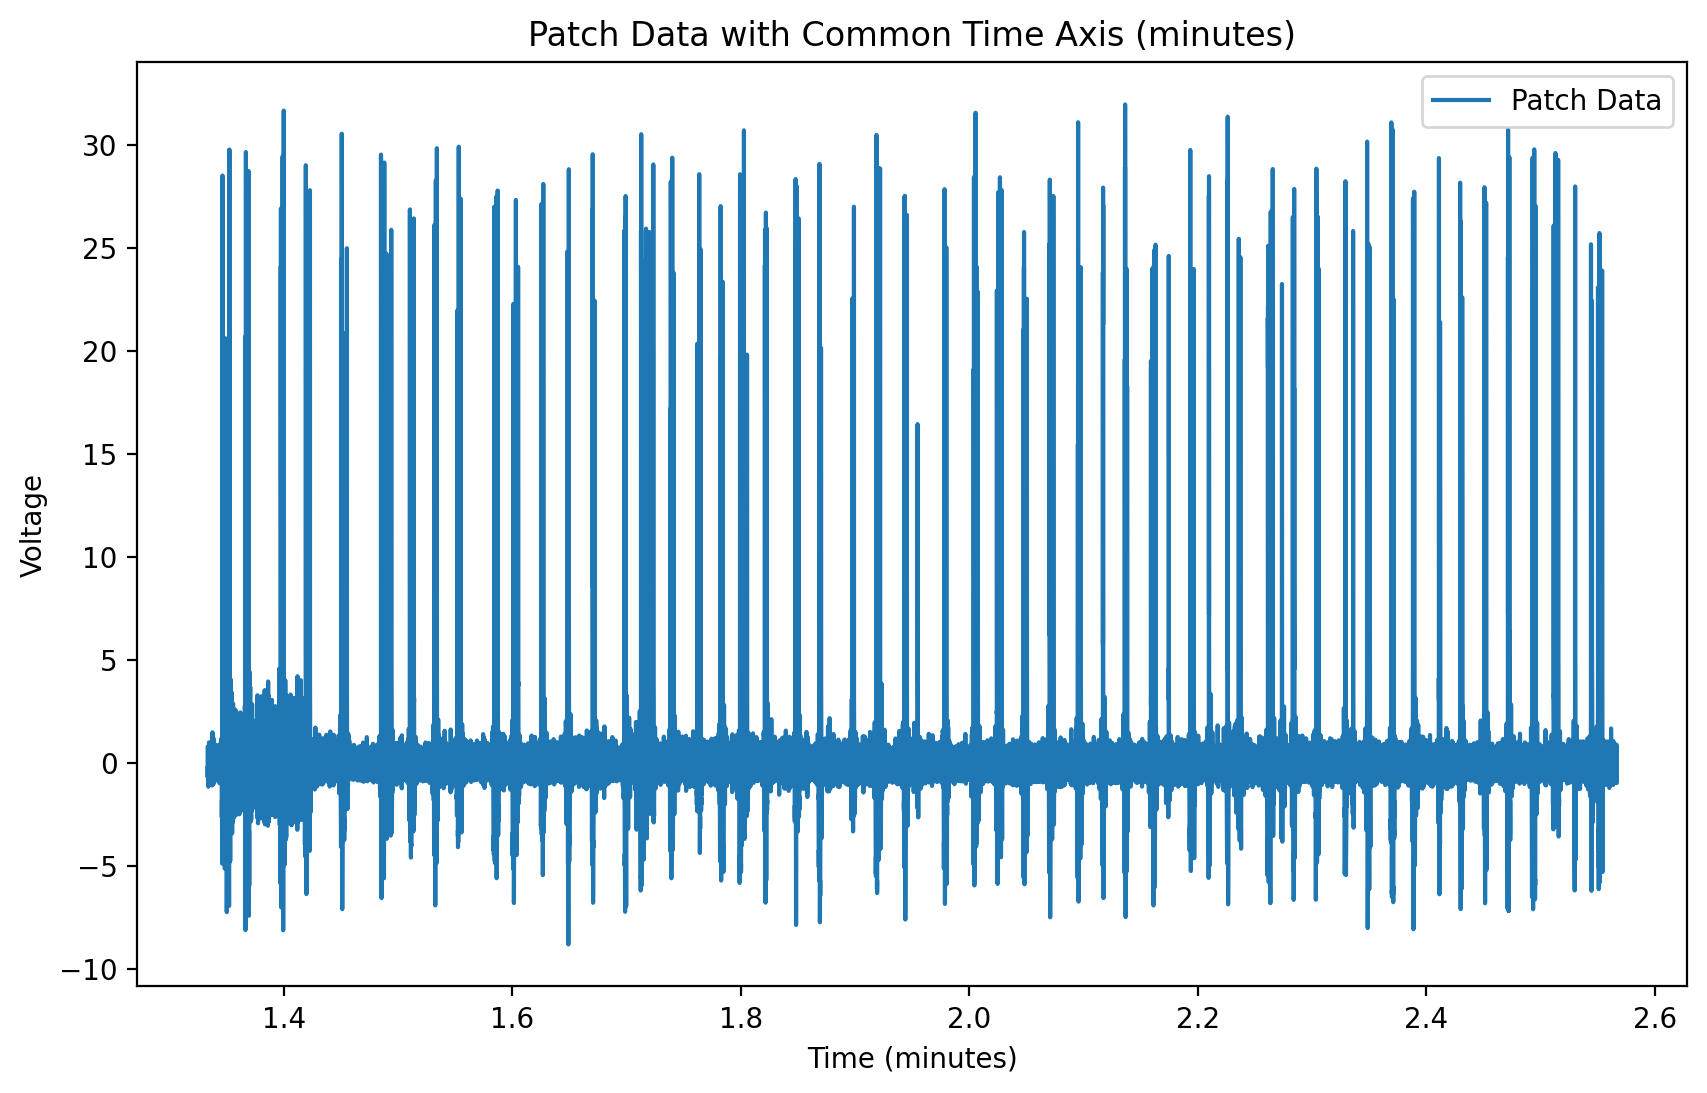

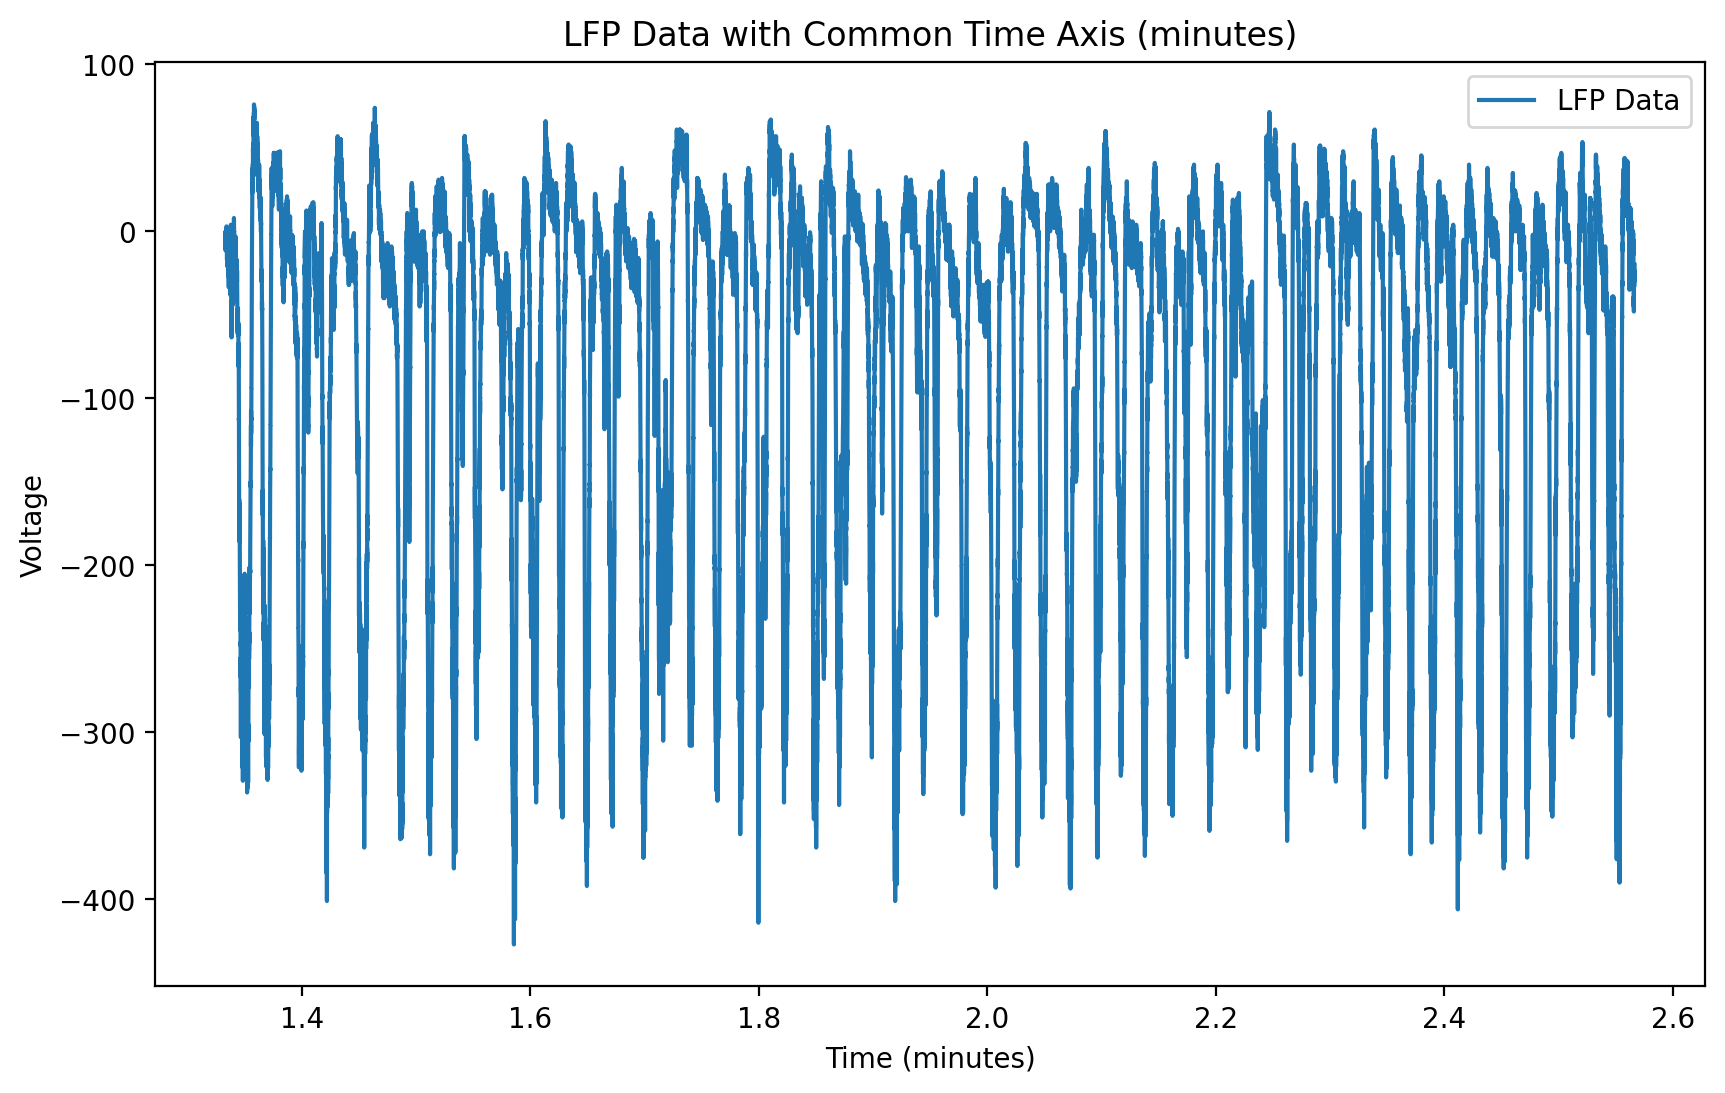

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

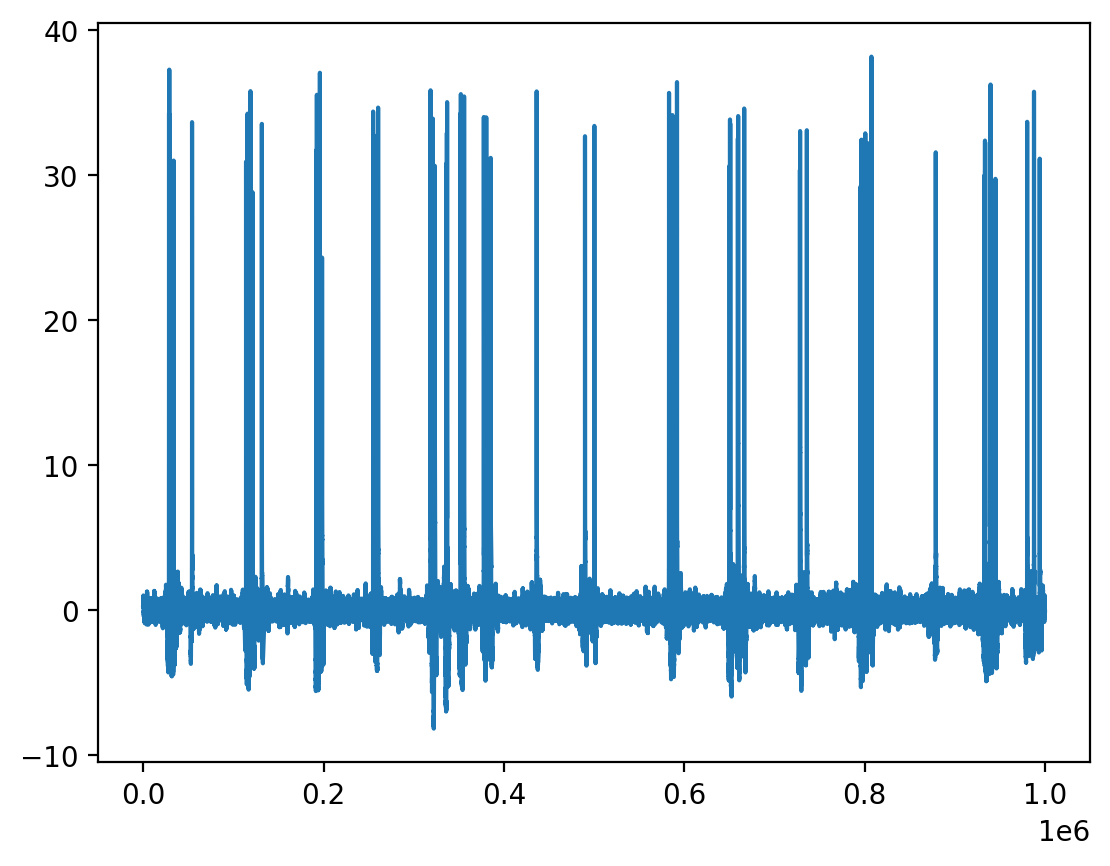

In [7]:
plt.plot(patch_filt[:1000000] )

In [8]:



#threshold in mVs
sp = Spike(thresh_amp=15, window_length=(5., 5.), smooth_frac=.01)

In [9]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=False)

Spike:   0%|          | 0/1496 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


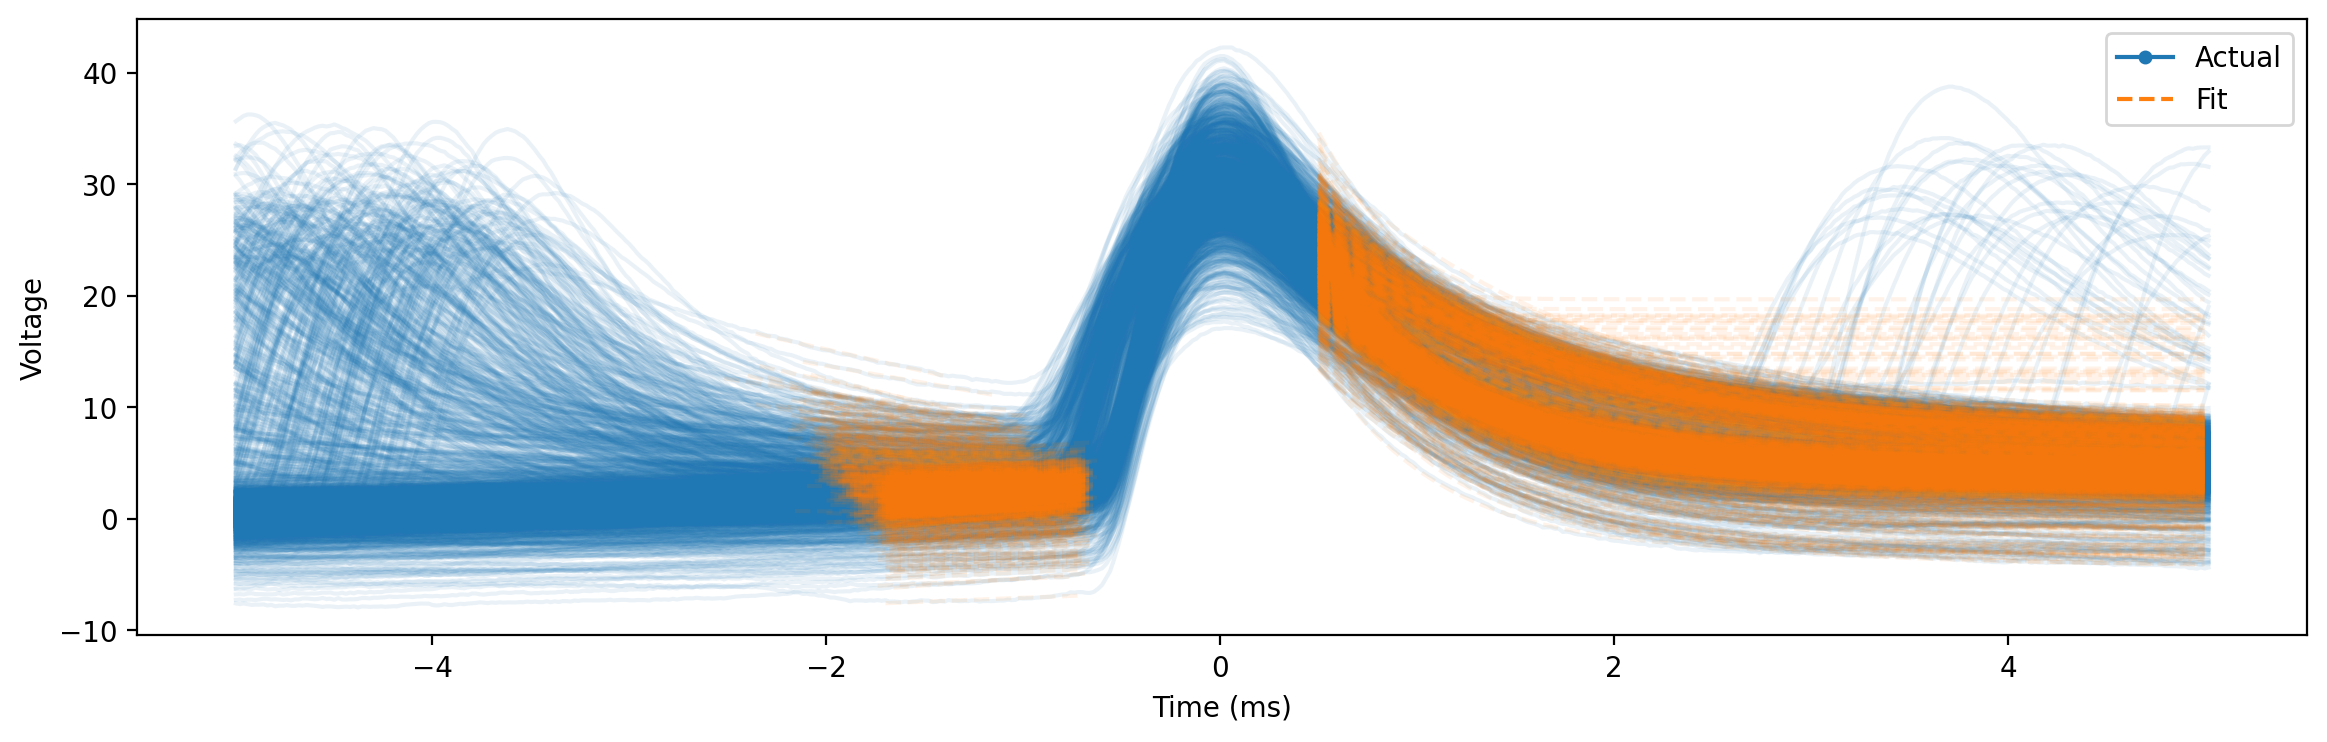

In [10]:
sp.plot()

### Filter spikes 

In [11]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [12]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [13]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1
3,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2
4,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3
6,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1491,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405
1492,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406
1493,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407
1494,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408


### Get spike times


In [14]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster ISI spike groups 

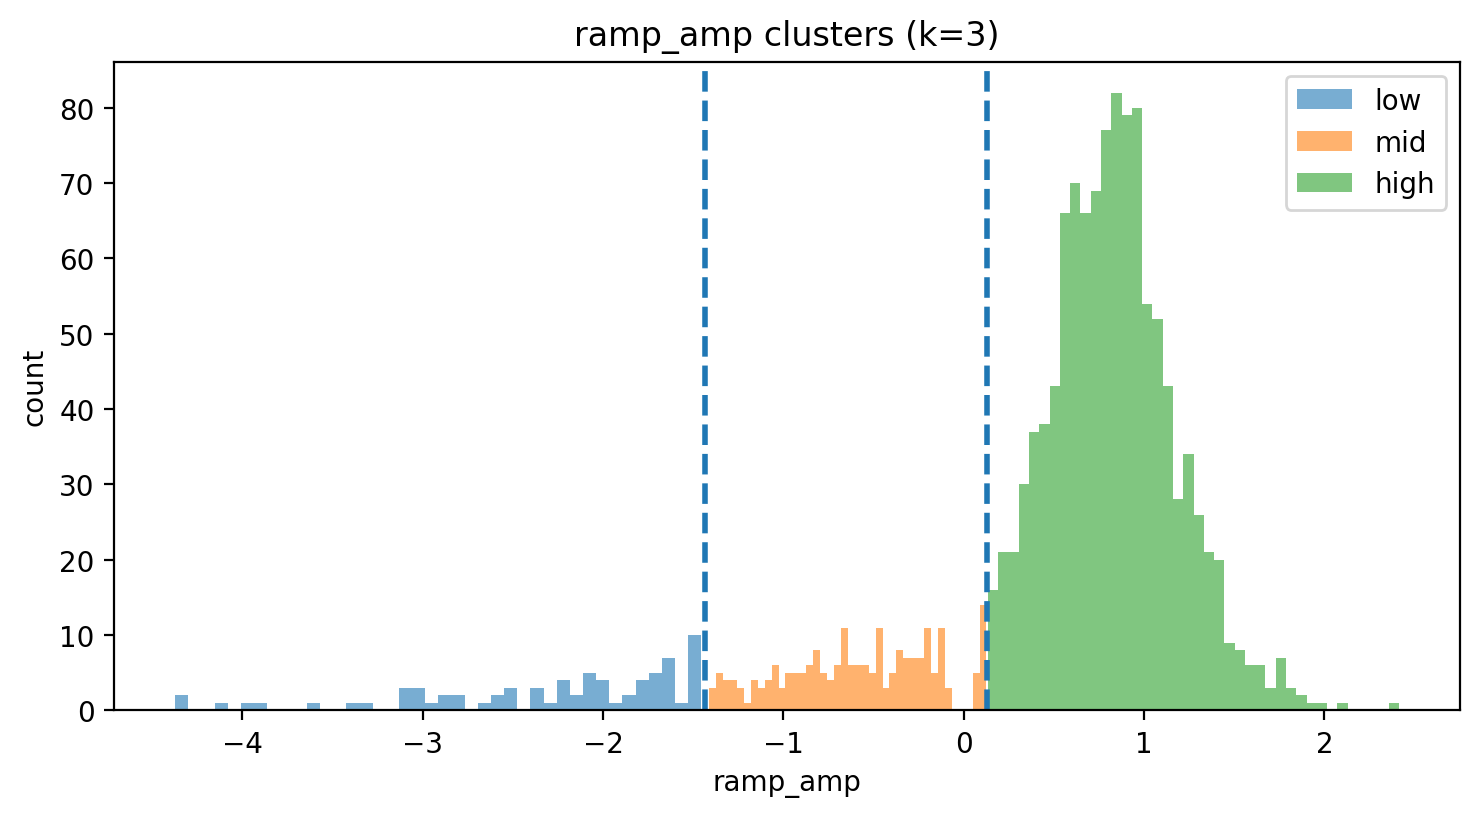

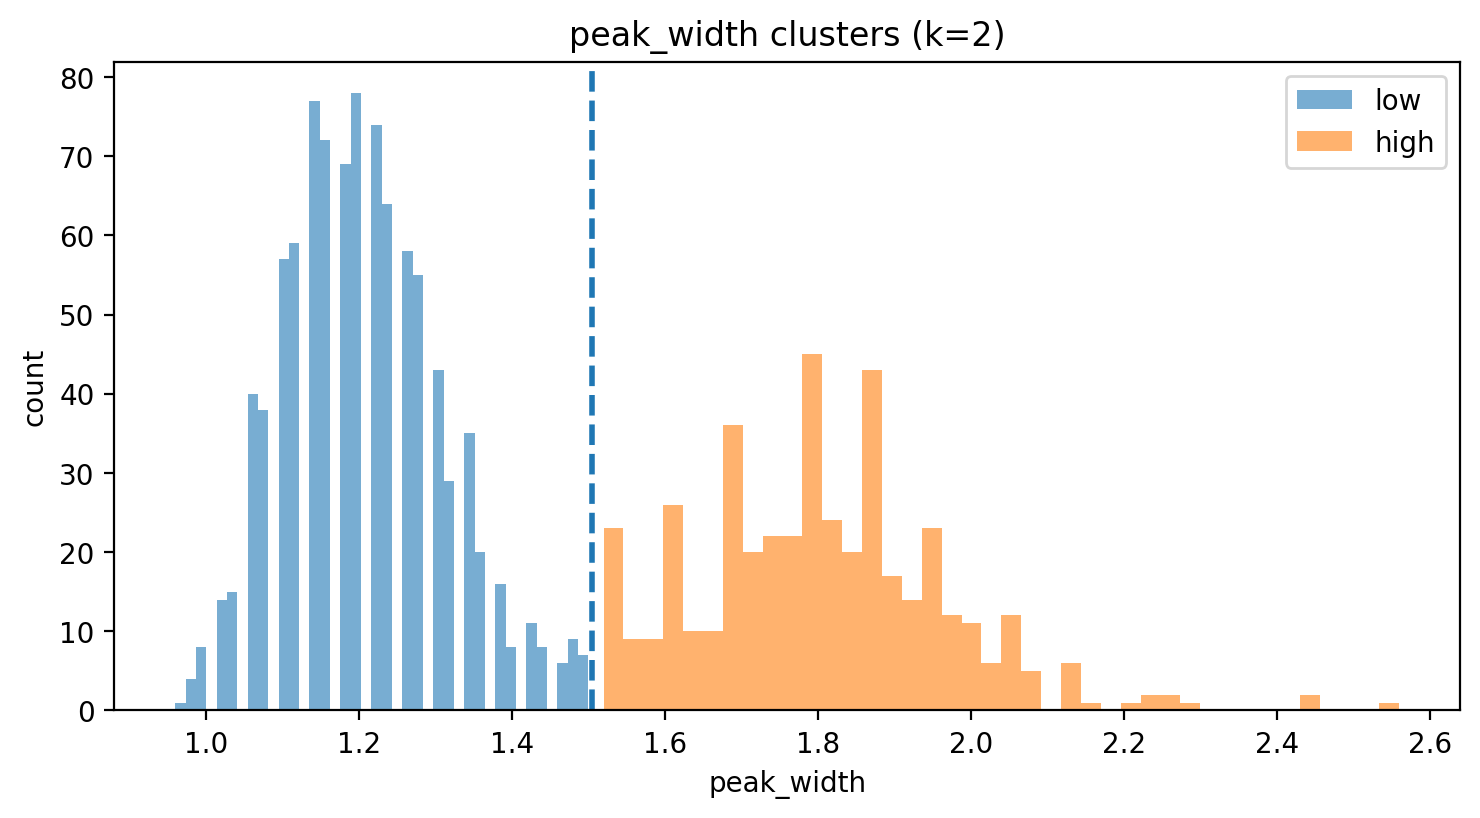

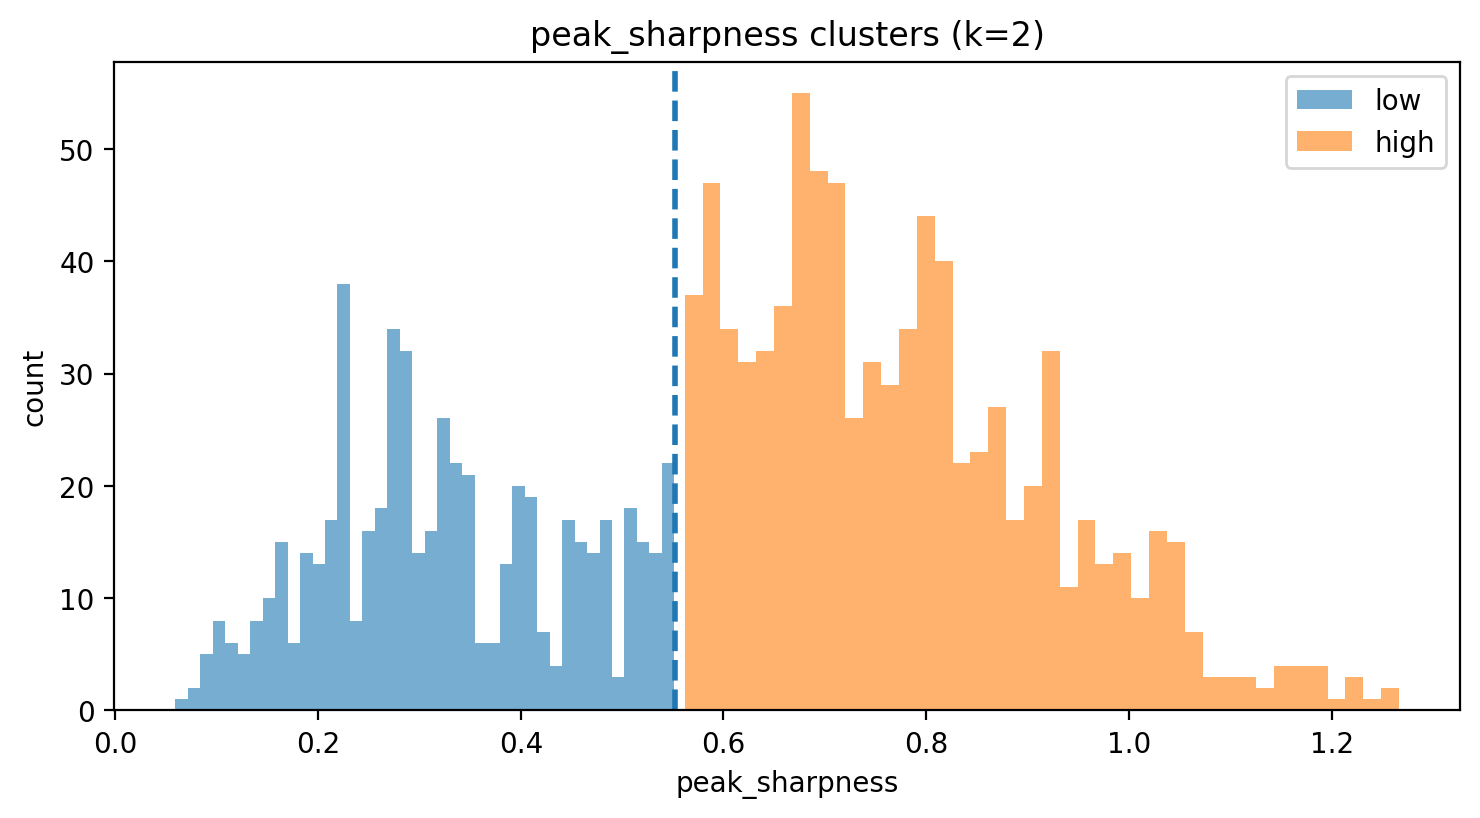

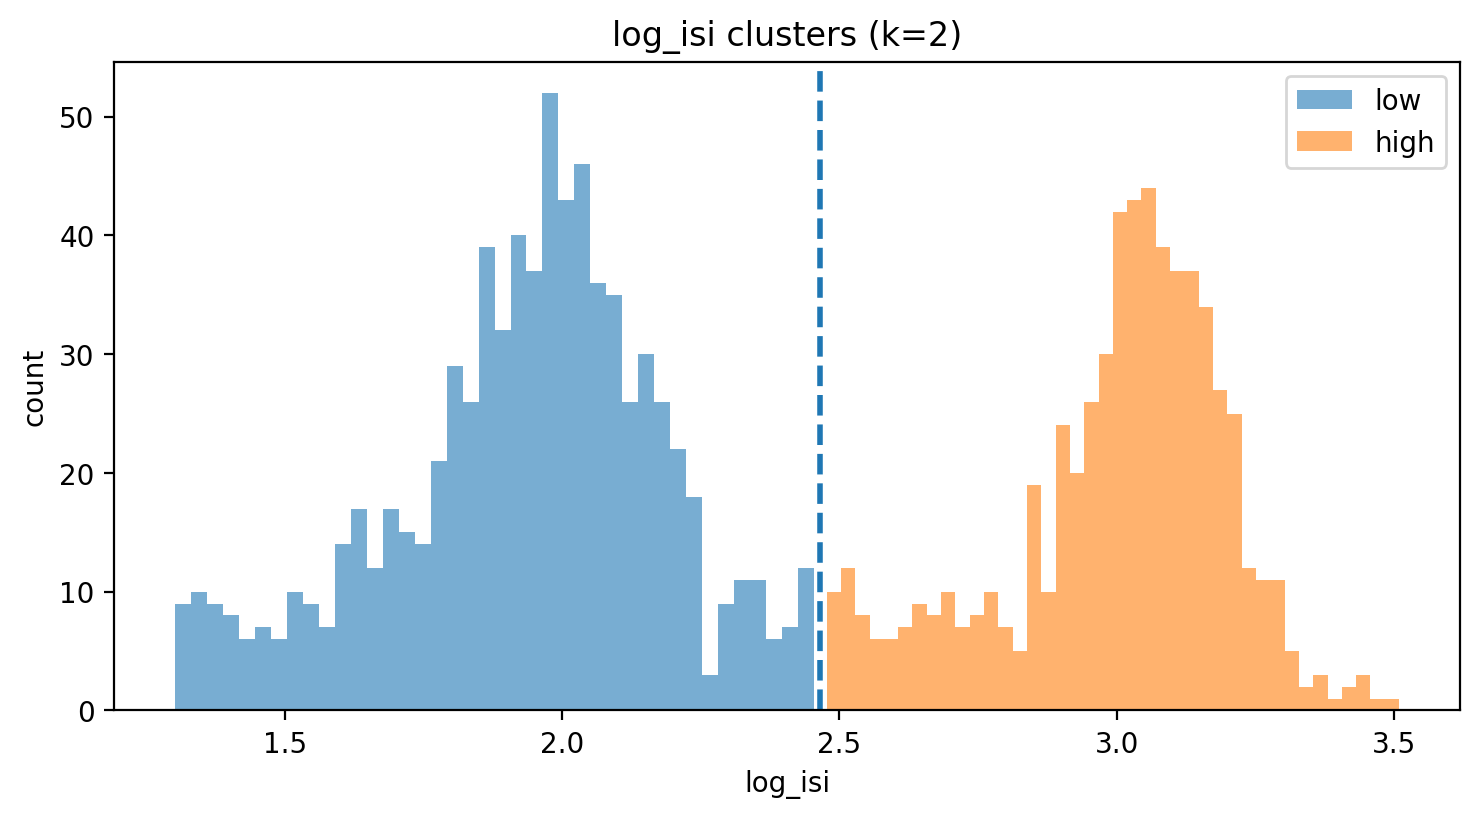

In [15]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=3,
    suffix="_cluster",
    plot_each=True  # set True if you want a quick plot per clustered feature
)







In [16]:
df_features_clust

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,ramp_amp_cluster,peak_width_cluster,peak_sharpness_cluster,log_isi_cluster
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0,high,high,low,low
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1,high,low,high,low
3,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2,high,low,high,high
4,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3,high,low,high,low
6,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4,high,low,high,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405,high,low,high,low
1492,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406,high,low,high,high
1493,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407,high,low,low,low
1494,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408,high,low,high,low


### STETP 3: Separate spikes into short ISIs and long ISIs and find transition points (long ISI spikes to group of short ISI spikes)

#### Visualize ISI spike cluster groups over time 

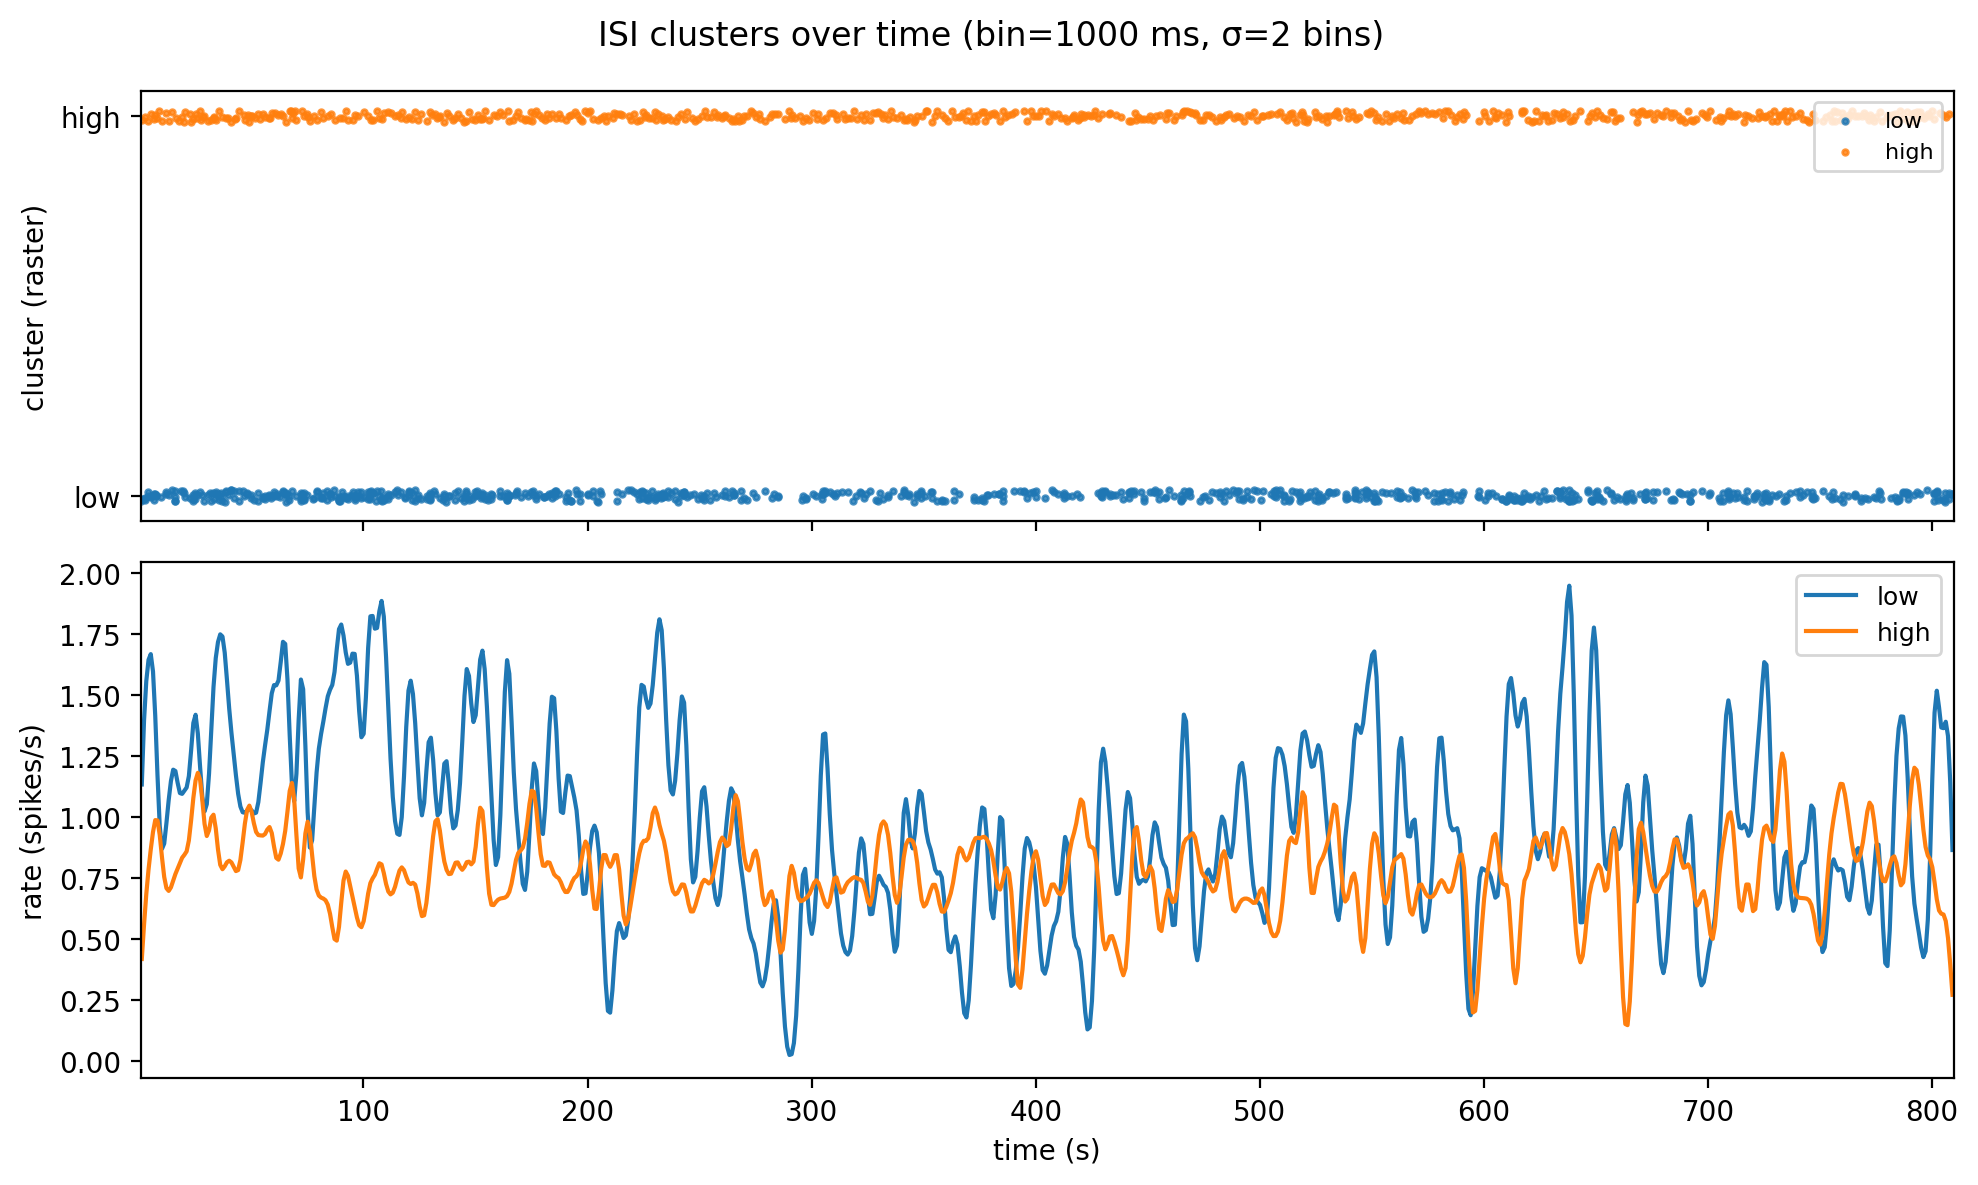

In [17]:
plot_clusters_over_time_min(
    df_features_clust,
    time_col="spk_times_ms",
    label_col="log_isi_cluster",   # your labels are 'low'/'high'
    time_unit="ms",
    bin_size_ms=1000,
    sigma_bins=2
)


#### Calculate transition probabilities 

          high       low
high  0.279743  0.720257
low   0.569975  0.430025


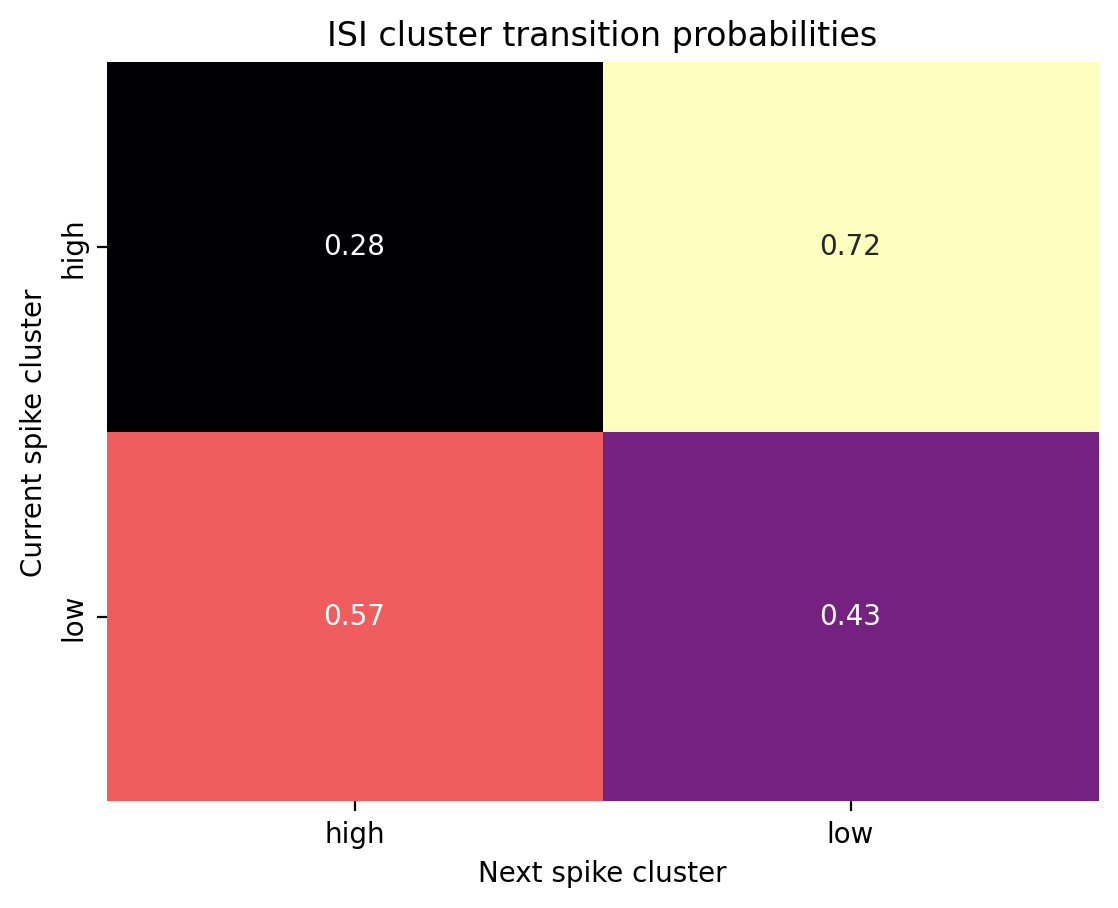

In [18]:
trans_mat = isi_transition_matrix(df_features_clust, "log_isi_cluster")
print(trans_mat)

sns.heatmap(trans_mat, annot=True, cmap="magma", cbar=False)
plt.title("ISI cluster transition probabilities")
plt.xlabel("Next spike cluster")
plt.ylabel("Current spike cluster")
plt.show()


#### Find transition points 

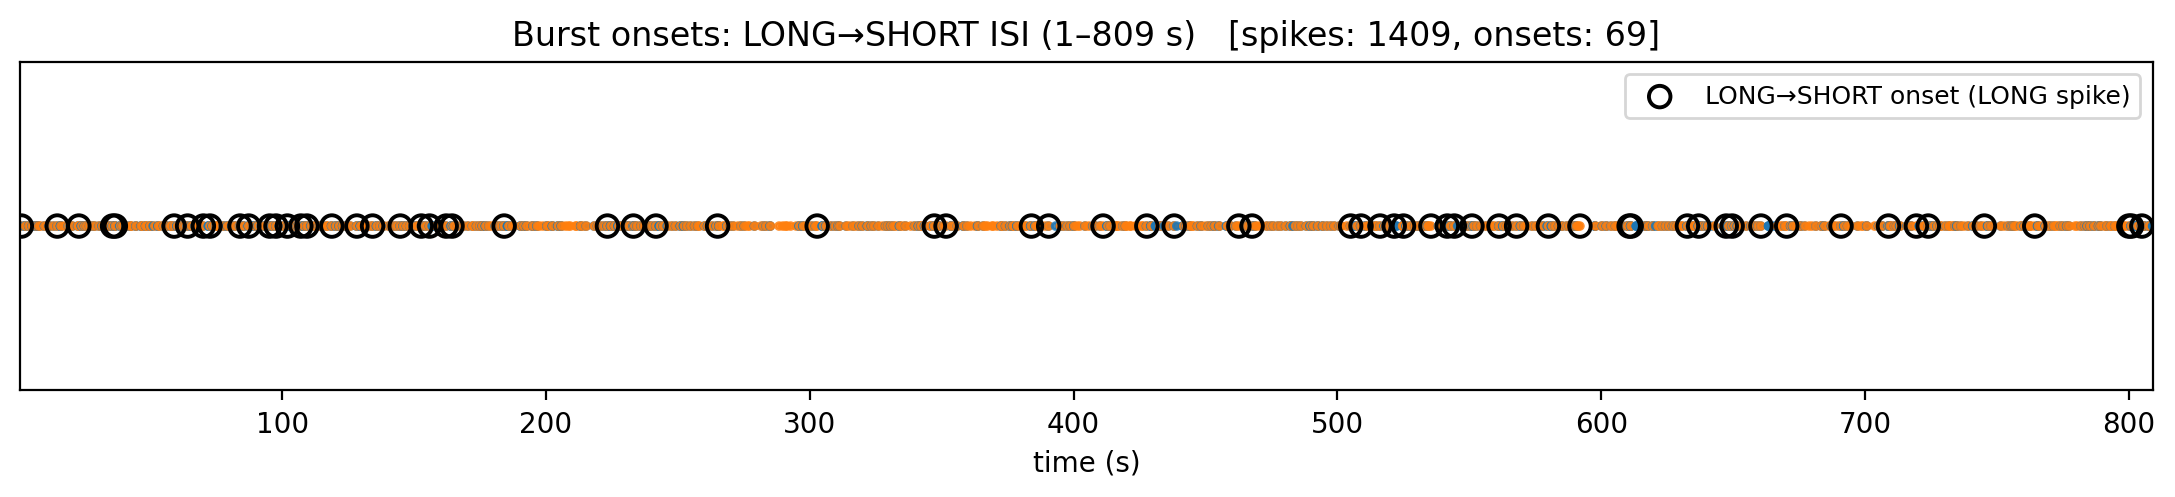

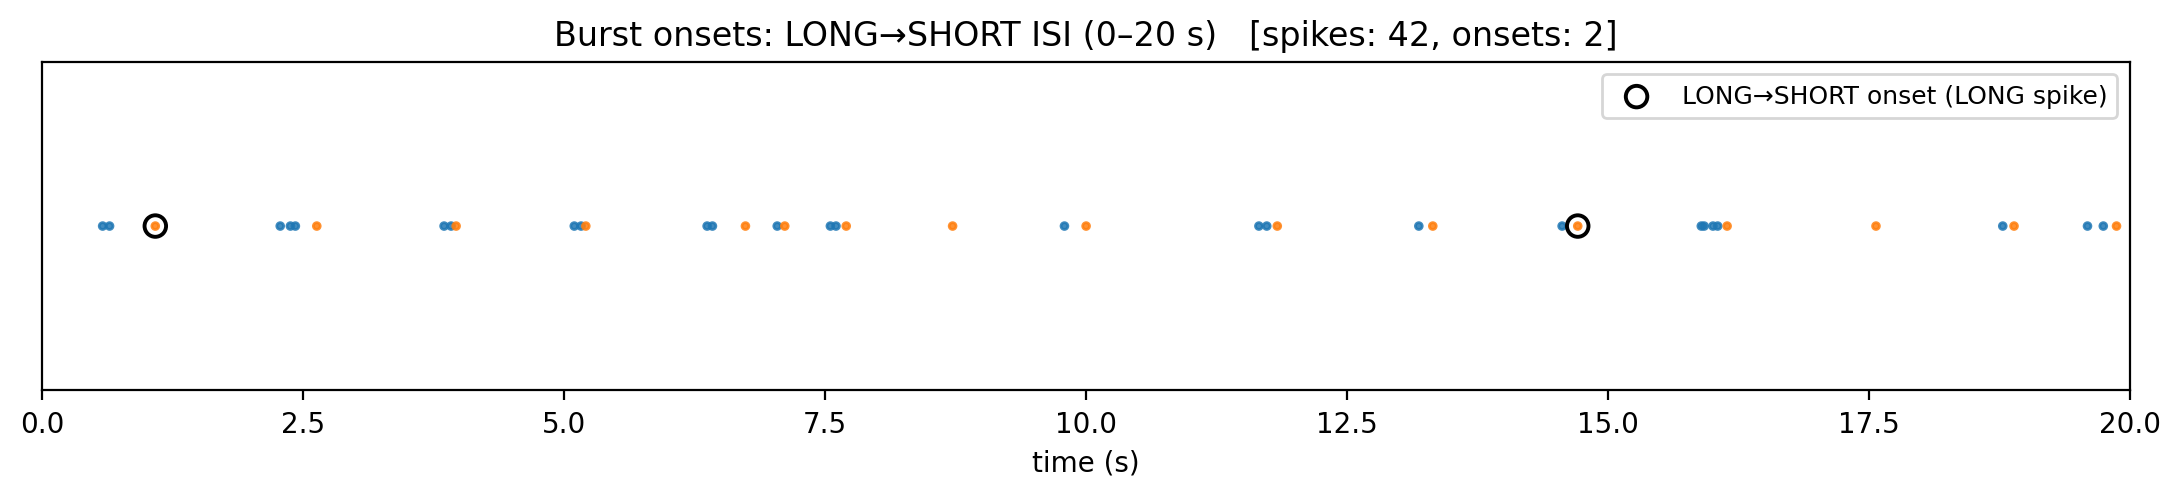

In [19]:
# Identify high spikes that start low bursts
df_marked = mark_high_burst_onsets(
    df_features_clust,
    cluster_col="log_isi_cluster",
    time_col="spk_times_ms",
    min_low_run=3  # how many LOW spikes must follow to count as a burst
)

# Plot full timeline
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster"          

)


# Zoom into a specific range 
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster",
    time_range=(00, 20)  # seconds
)


In [20]:
df_marked

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,ramp_amp_cluster,peak_width_cluster,peak_sharpness_cluster,log_isi_cluster,is_long_to_short_isi_onset
0,0.831264,0.76,2.175625,37.159431,1.54,0.488185,1.060599,6.280598,1.822091,28974,579.203281,0,high,high,low,low,False
1,1.301123,0.68,2.432262,26.044590,1.28,0.565906,0.785925,1.198710,1.469320,32295,645.591564,1,high,low,high,low,False
2,1.208969,0.66,1.659889,33.597074,1.08,0.883541,1.675188,2.721035,3.078032,54213,1083.742234,2,high,low,high,high,True
3,0.901014,0.66,-1.549076,30.813059,1.12,0.899997,1.446296,-0.961640,1.517516,114083,2280.570440,3,high,low,high,low,False
4,0.848046,0.66,3.066991,35.618422,1.08,0.978739,1.788263,4.431164,1.679039,118955,2377.963910,4,high,low,high,low,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,1.045474,0.66,4.731849,38.264729,1.08,0.899013,1.643298,6.161639,1.922207,40394322,807500.650423,1405,high,low,high,low,False
1406,0.867023,0.72,3.797083,32.244505,1.14,0.731312,1.293713,3.493535,3.164163,40398504,807584.250482,1406,high,low,high,high,False
1407,0.927436,0.74,3.426125,25.883916,1.48,0.471966,0.963138,5.629404,1.815370,40471507,809043.613260,1407,high,low,low,low,False
1408,0.579992,0.64,4.471907,36.945890,1.06,0.991244,1.668280,4.414232,1.683380,40474777,809108.982030,1408,high,low,high,low,False


#### Look at the other waveform features for the "transition" spikes
There are no significant differences in the waveform features forr the transition spikes vs other spikes

ramp_amp            : t-test        (p=0.6)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


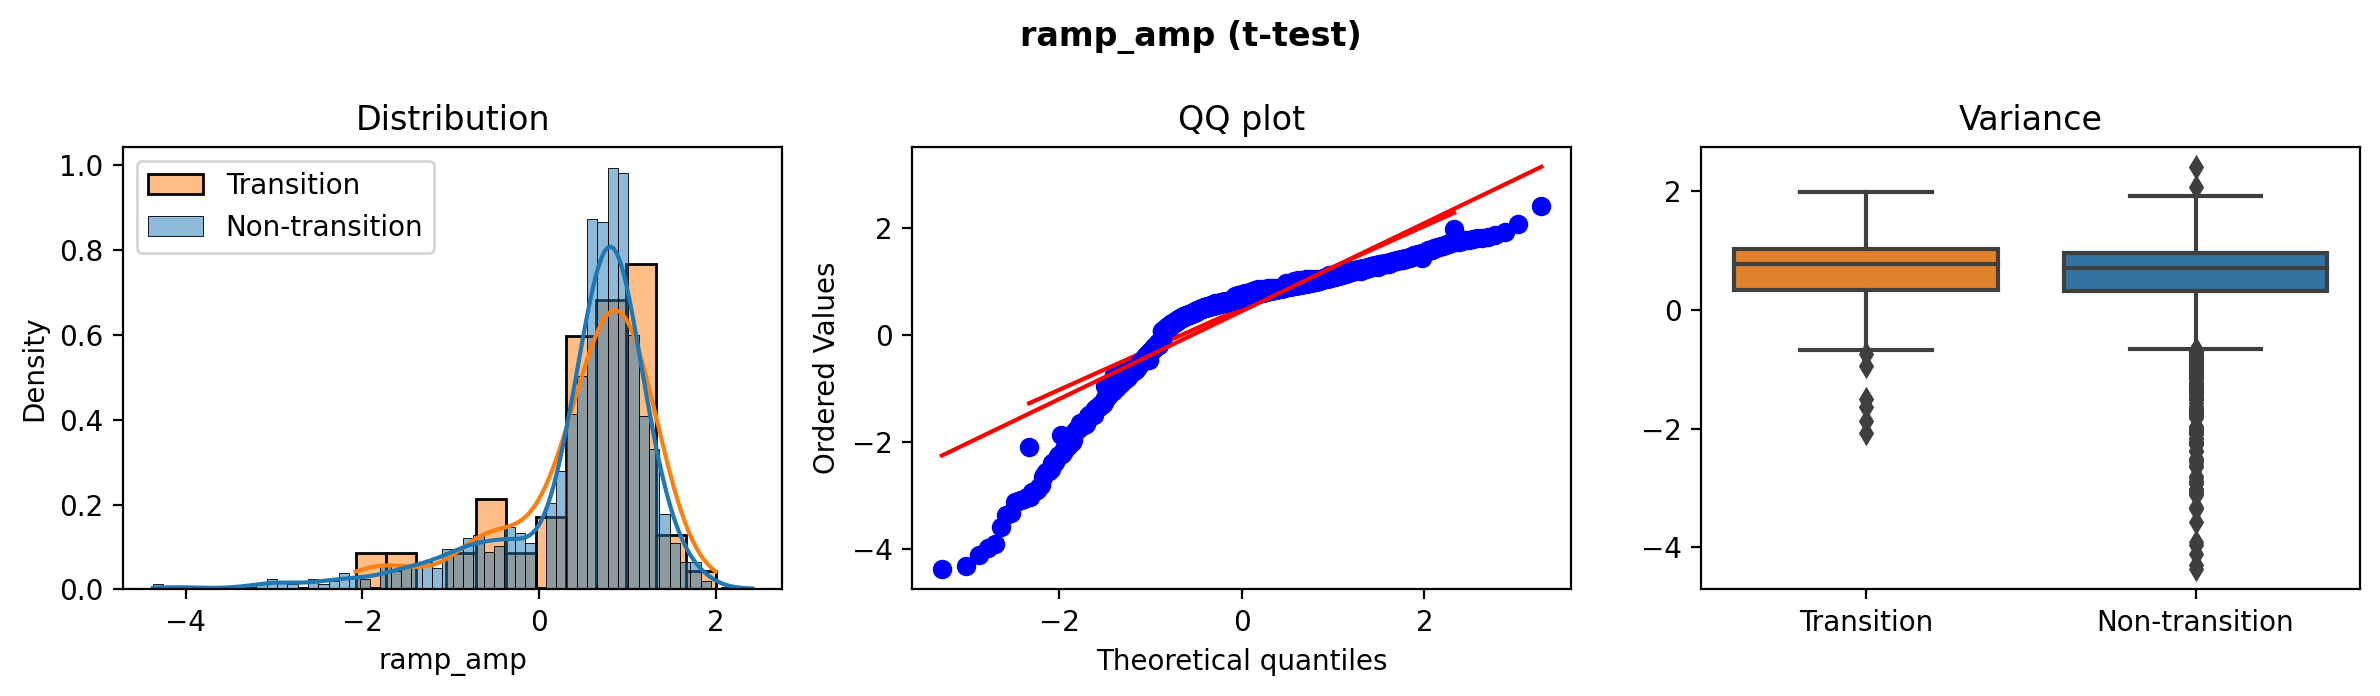

peak_width          : t-test        (p=0.89)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used


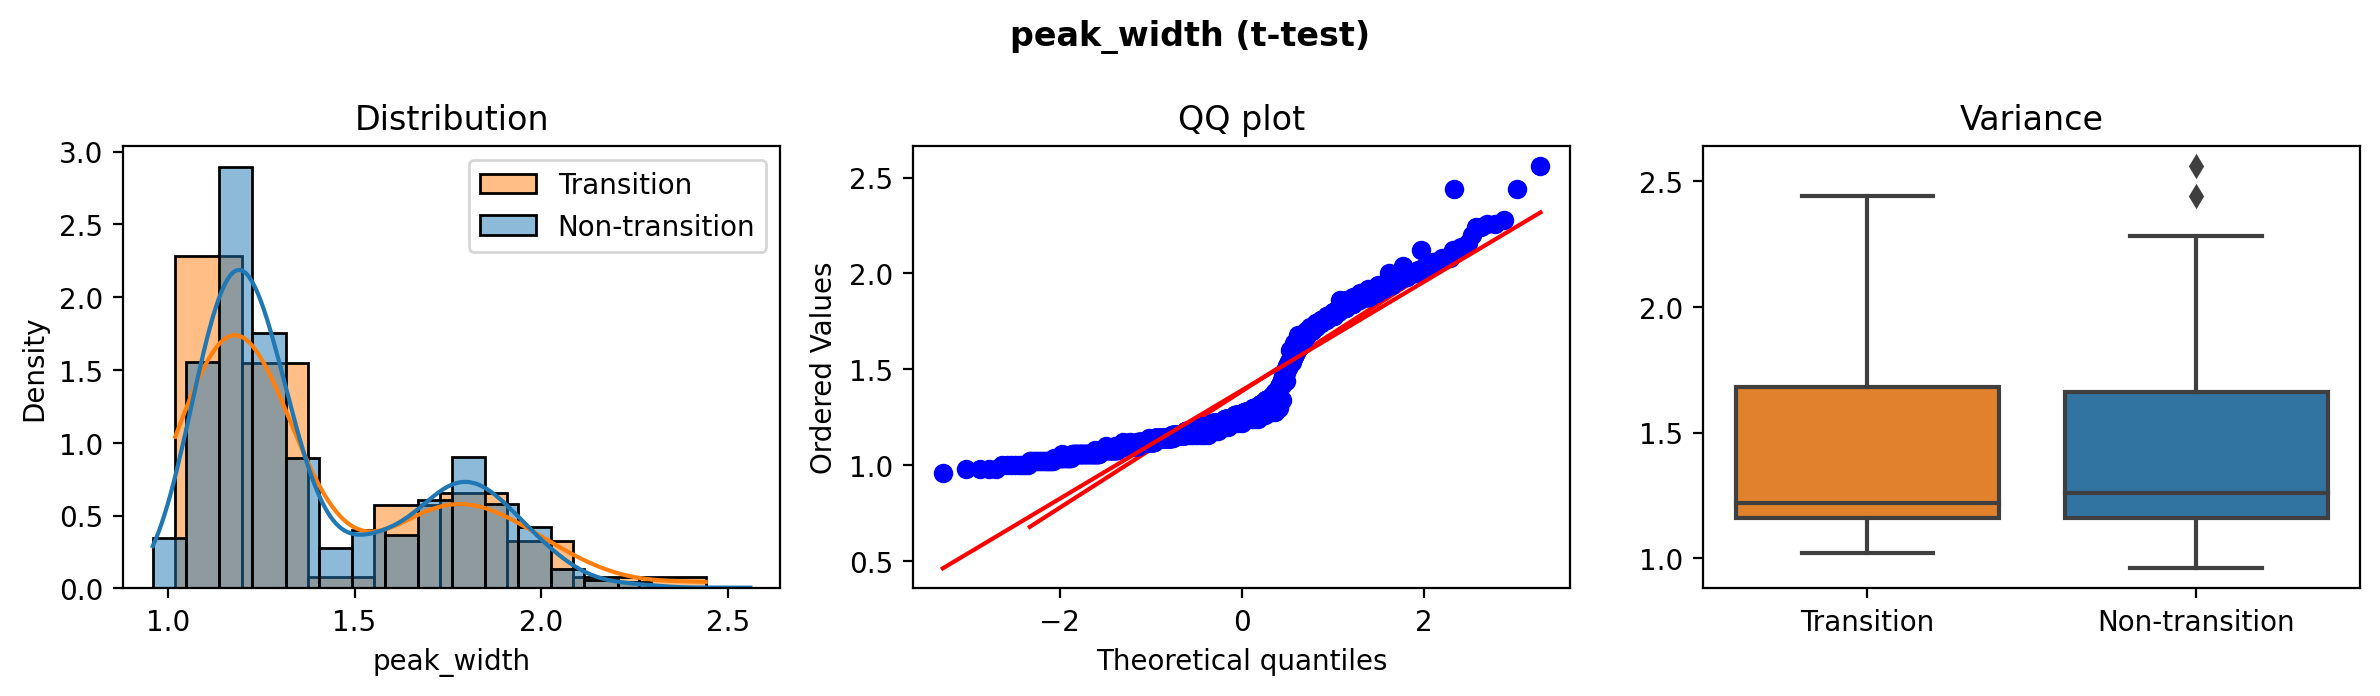

peak_sharpness      : t-test        (p=0.576)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used


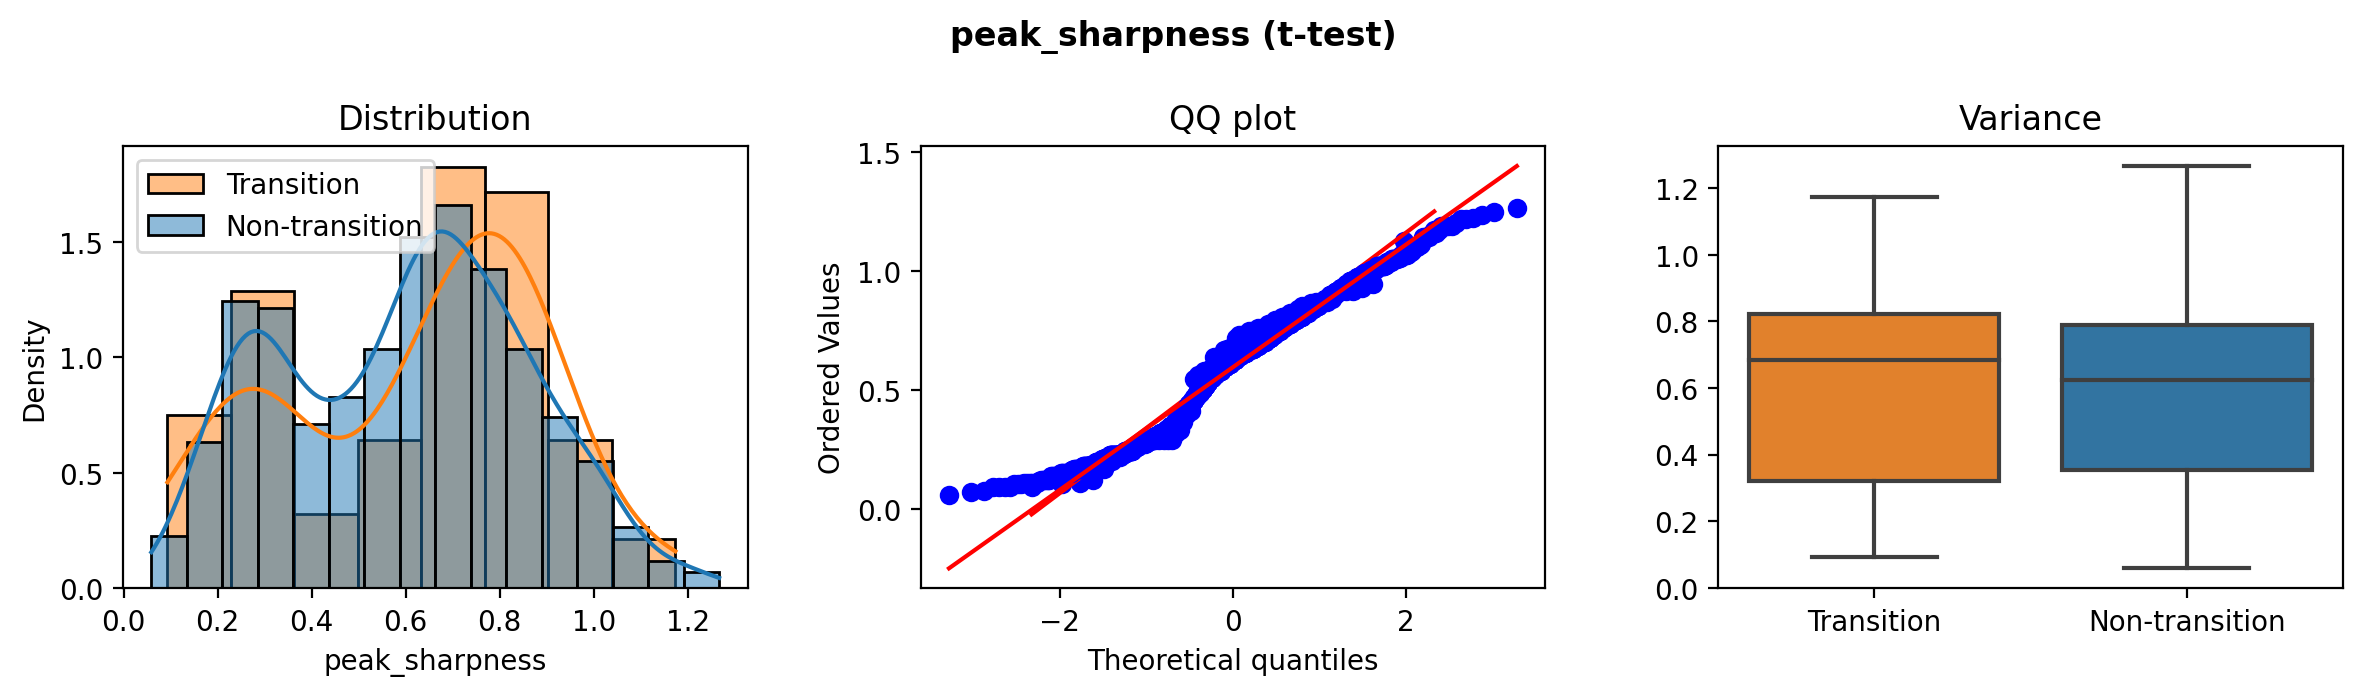

inflection_amp      : t-test        (p=0.3)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used


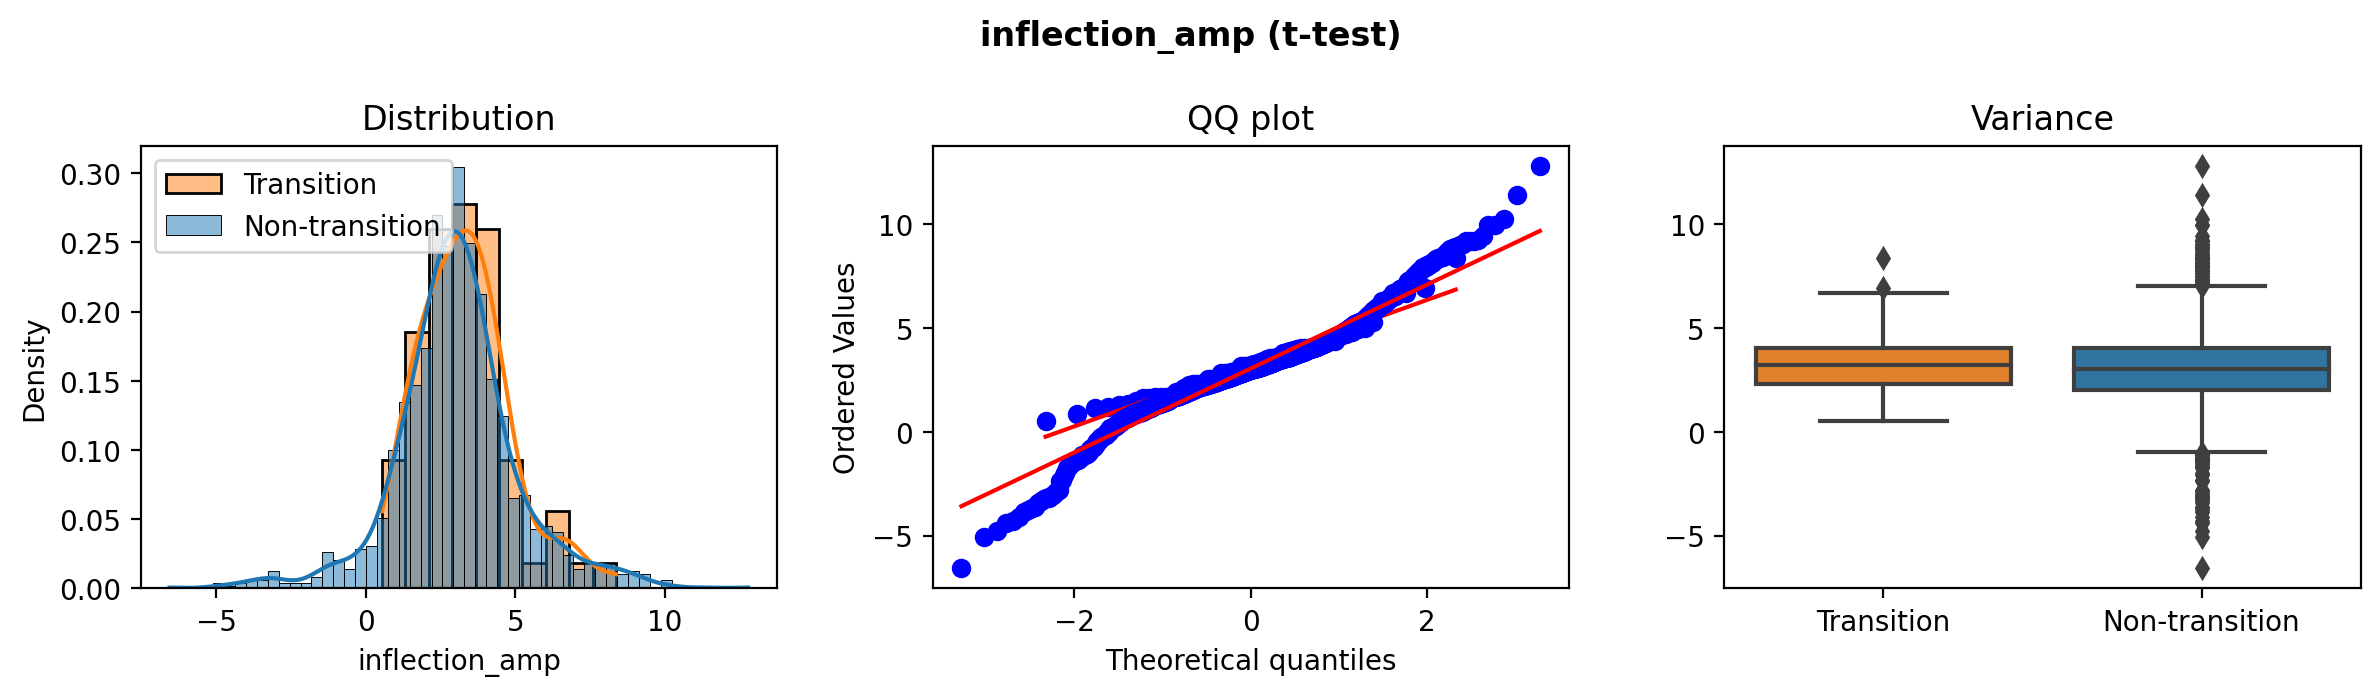

exp_lambda          : t-test        (p=0.692)  | normal_a=True, normal_b=True, equal_var=True → normal or large n → t-test used


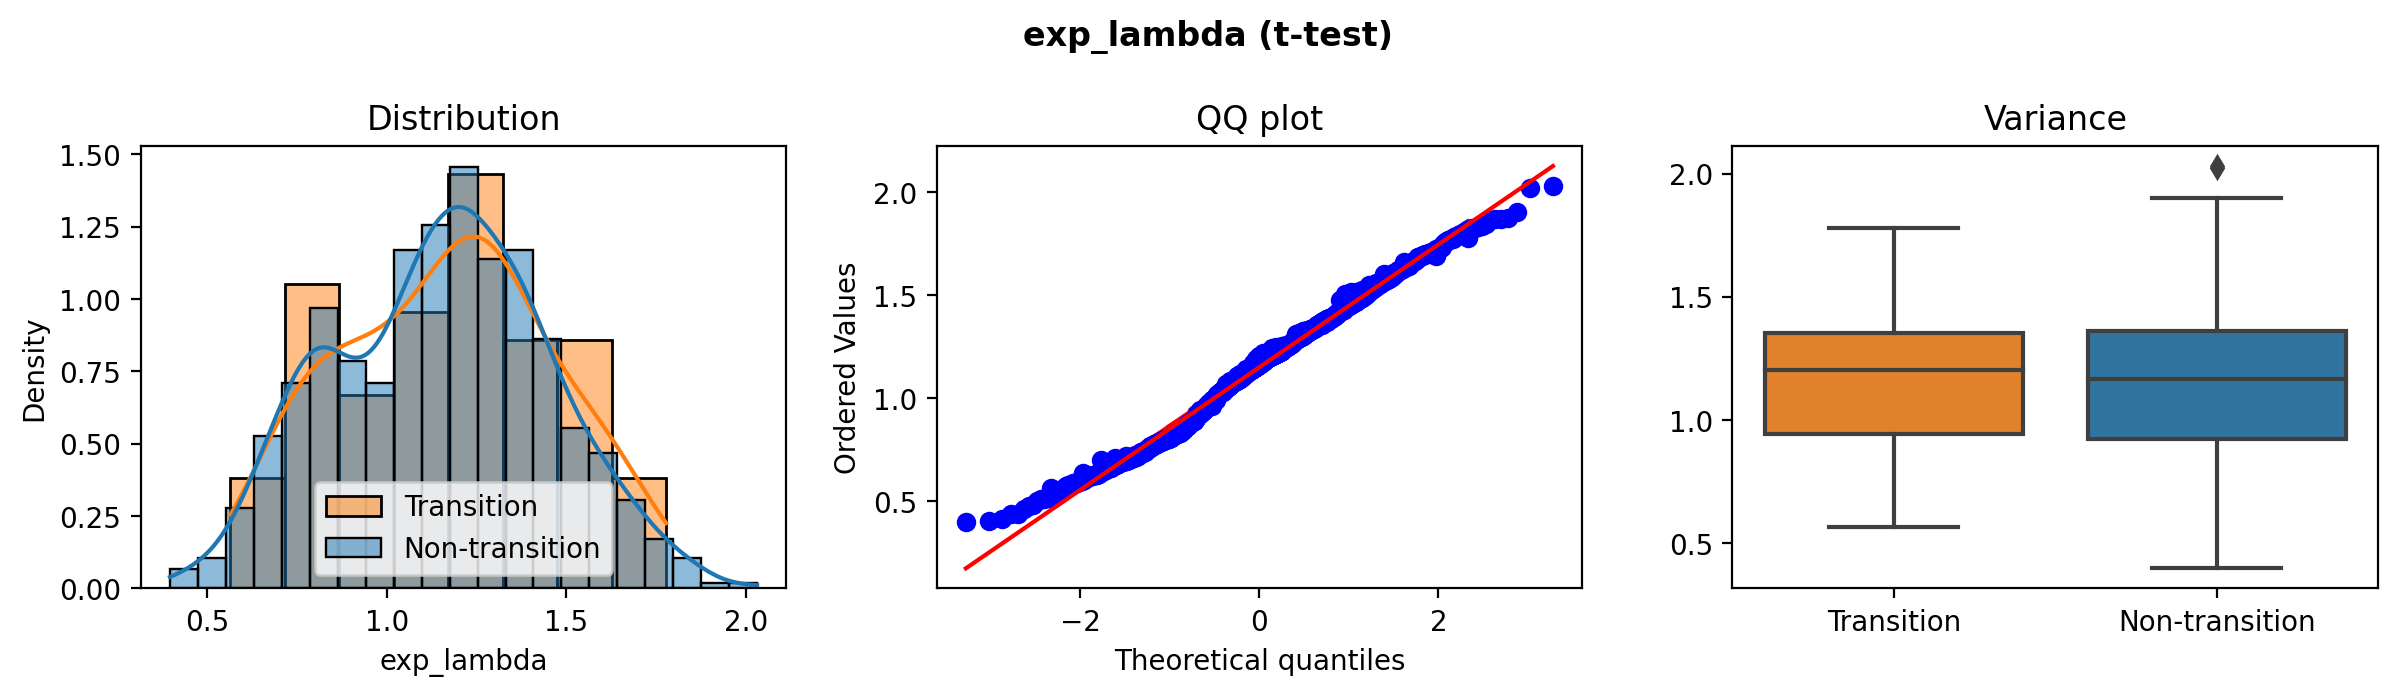

In [21]:

features = ["ramp_amp", "peak_width", "peak_sharpness", "inflection_amp", "exp_lambda"]

res = compare_transition_features(df_marked, features)



### STEP 4: Analyze LFP around transition points

#### Get LFP windows 

Removed 1 transition(s) with next_log_isi > 1.122


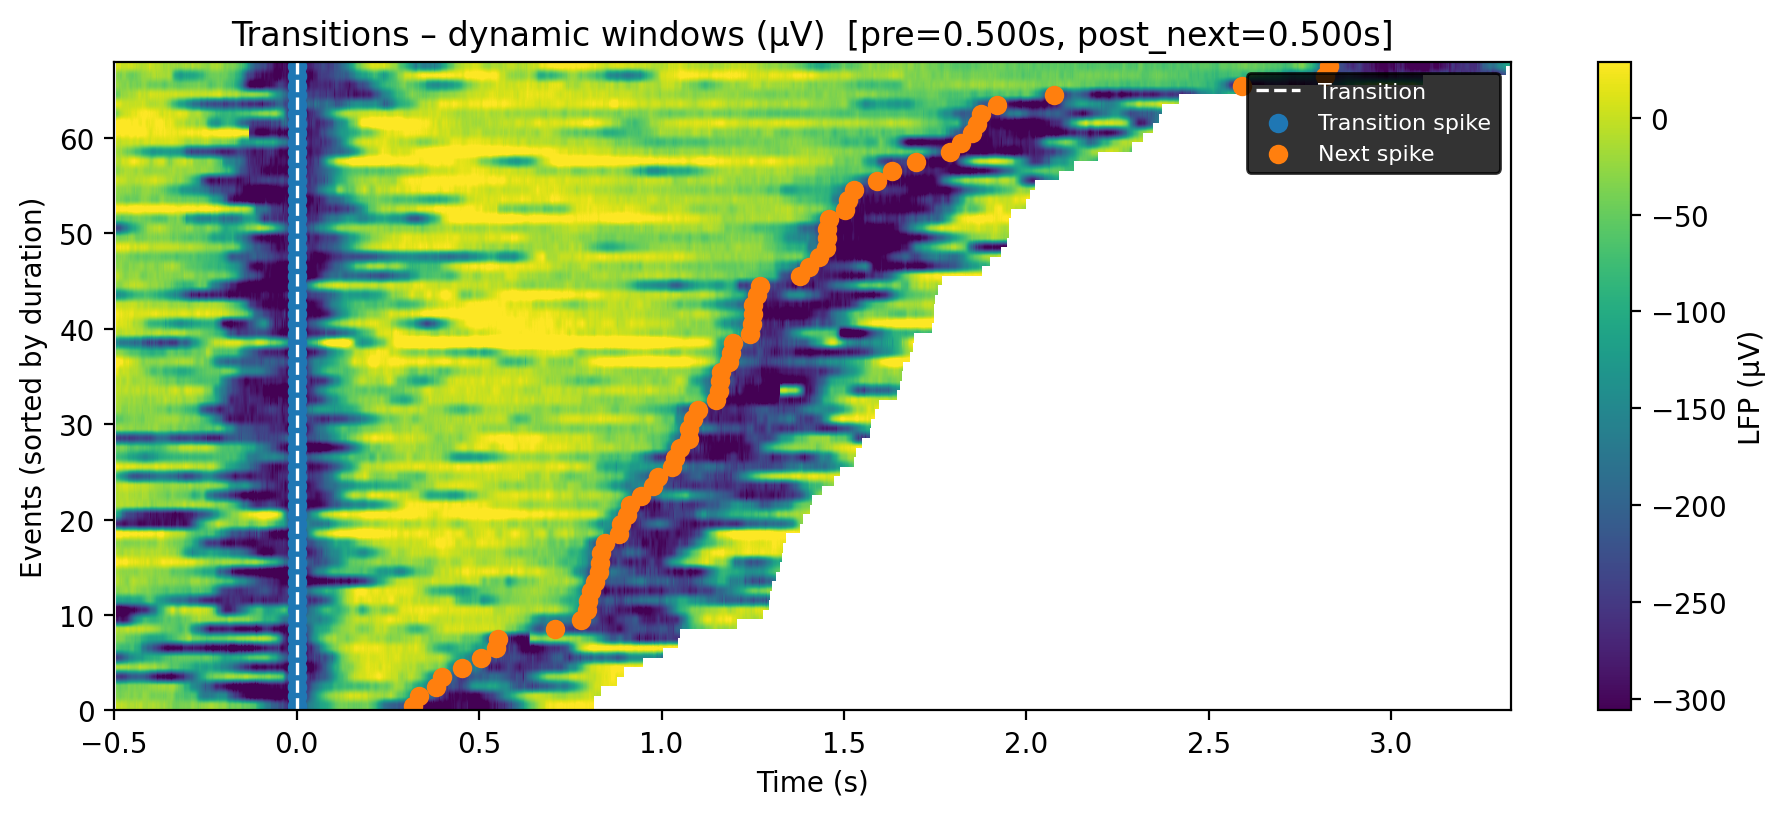

In [22]:

# 1) Compute NEXT-ISI from your spike-time column (in ms → s)
df_marked = df_marked.sort_values("spk_times_ms").reset_index(drop=True)
t_ms = pd.to_numeric(df_marked["spk_times_ms"], errors="coerce")

# time to next spike (ms), last row → NaN
df_marked["next_isi_ms"] = (t_ms.shift(-1) - t_ms).astype(float)
df_marked.loc[df_marked["next_isi_ms"] <= 0, "next_isi_ms"] = np.nan

# seconds and log (natural log to match your existing log_isi scale)
df_marked["next_isi_s"]   = df_marked["next_isi_ms"] / 1000.0
df_marked["next_log_isi"] = np.log(df_marked["next_isi_s"])


# 2) Remove long NEXT-ISI outliers among transitions
mask_trans = df_marked["is_long_to_short_isi_onset"].astype(bool)
isis_next  = df_marked.loc[mask_trans, "next_log_isi"].dropna()

thr = isis_next.mean() + 2 * isis_next.std()
bad = mask_trans & (df_marked["next_log_isi"] > thr)

df_marked.loc[bad, "is_long_to_short_isi_onset"] = False
print(f"Removed {bad.sum()} transition(s) with next_log_isi > {thr:.3f}")

# 3) Rebuild transitions AFTER filtering
transitions = transition_next_isi_windows(
    df_marked, time_col="spk_times_ms", onset_col="is_long_to_short_isi_onset"
)

# 4) Re-extract & plot dynamic windows
pre_s, post_after_next_s = 0.500, 0.500
dyn_df, dyn_wins, dyn_t = extract_transition_windows_dynamic(
    lfp_uv=lfp_filt, fs=lfp_fs,
    transitions_df=transitions,
    pre_s=pre_s, post_after_next_s=post_after_next_s
)

t_next_rel = (dyn_df["next_time_s"] - dyn_df["onset_time_s"]).to_numpy(float)
plot_transition_heatmap(
    windows=dyn_wins, times=dyn_t,
    title=f"Transitions – dynamic windows (µV)  [pre={pre_s:.3f}s, post_next={post_after_next_s:.3f}s]",
    markers={"Transition spike": np.zeros(len(dyn_wins)),
             "Next spike": t_next_rel}
)


#### Control plots - also plot heatmaps for random non transition spikes
We are seeing a drop in LFP voltage before spikes for ALL spikes 

In [23]:
# Match the number of controls to transitions 
n_ctrl = len(dyn_df)  # dyn_df from ransitions pipeline
controls = make_random_control_table(
    df_marked,
    time_col="spk_times_ms",
    onset_col="is_long_to_short_isi_onset",
    n_controls=n_ctrl,
    random_state=42,
)

ctrl_df, ctrl_wins, ctrl_t = extract_transition_windows_dynamic(
    lfp_uv=lfp_filt, fs=lfp_fs,
    transitions_df=controls.rename(columns={"next_spike_time_s":"next_time_s"}),
    pre_s=pre_s, post_after_next_s=post_after_next_s
)


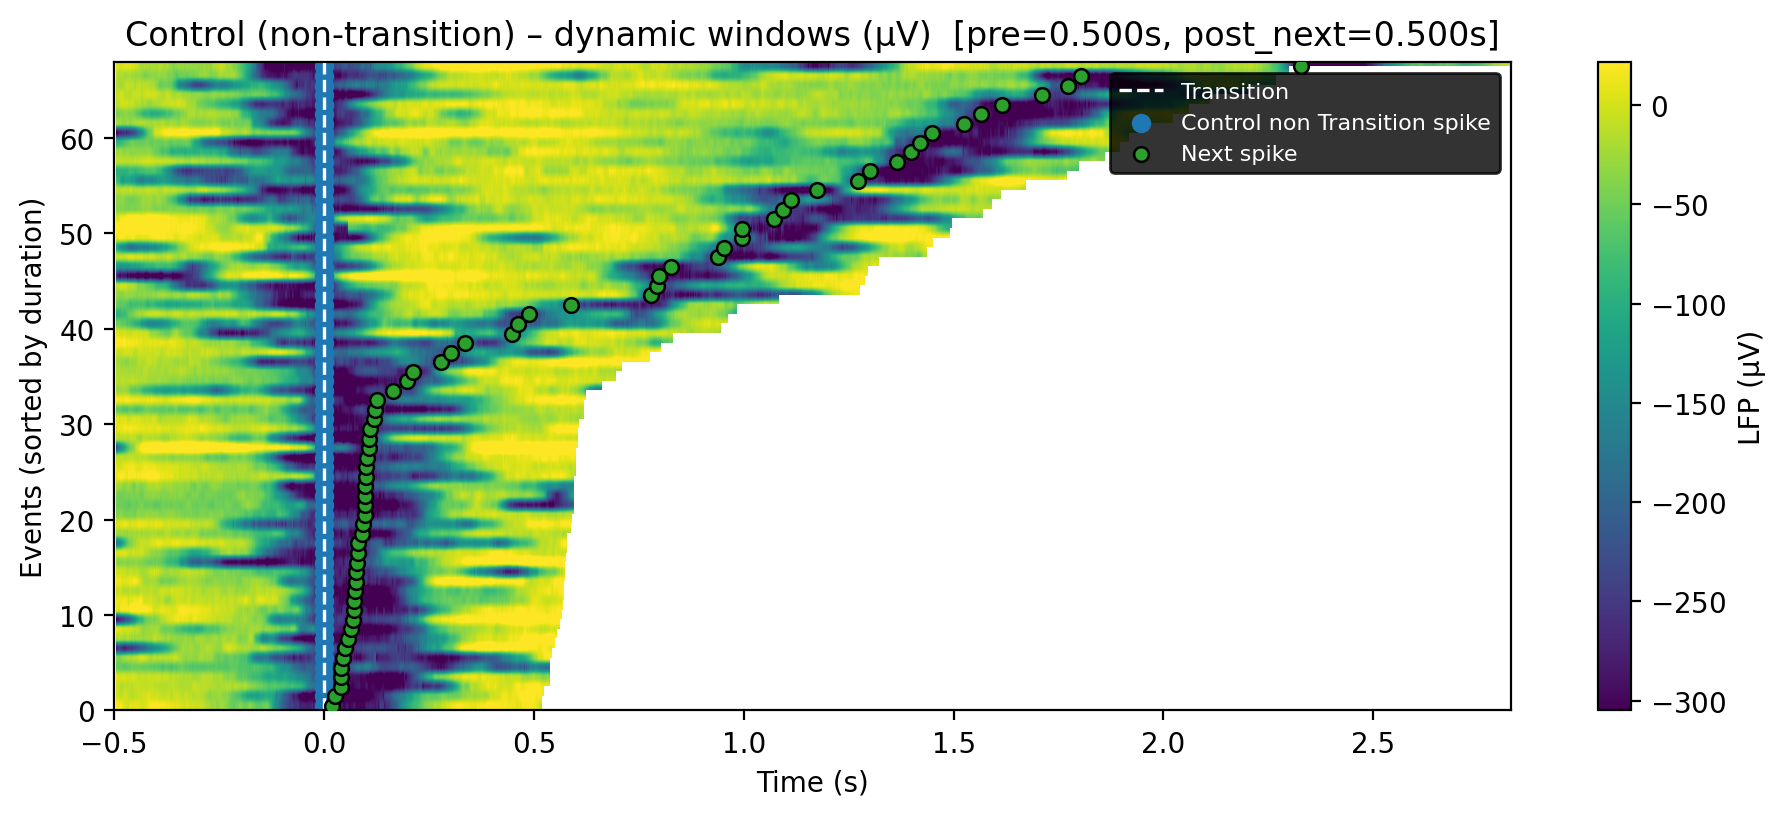

In [24]:
t_next_rel_ctrl = (ctrl_df["next_time_s"] - ctrl_df["onset_time_s"]).to_numpy(float)

plot_transition_heatmap(
    windows=ctrl_wins, times=ctrl_t,
    title=f"Control (non-transition) – dynamic windows (µV)  [pre={pre_s:.3f}s, post_next={post_after_next_s:.3f}s]",
    markers={"Control non Transition spike": np.zeros(len(ctrl_wins)),
             "Next spike": t_next_rel_ctrl},
    marker_style={
        "Anchor": {"s": 28, "facecolors": "white",  "edgecolors": "black", "lw": 0.9, "zorder": 6},
        "Next spike": {"s": 28, "facecolors": "#2ca02c", "edgecolors": "black", "lw": 0.9, "zorder": 6},
    }
)


#### Analyze LFP windows using specparam 

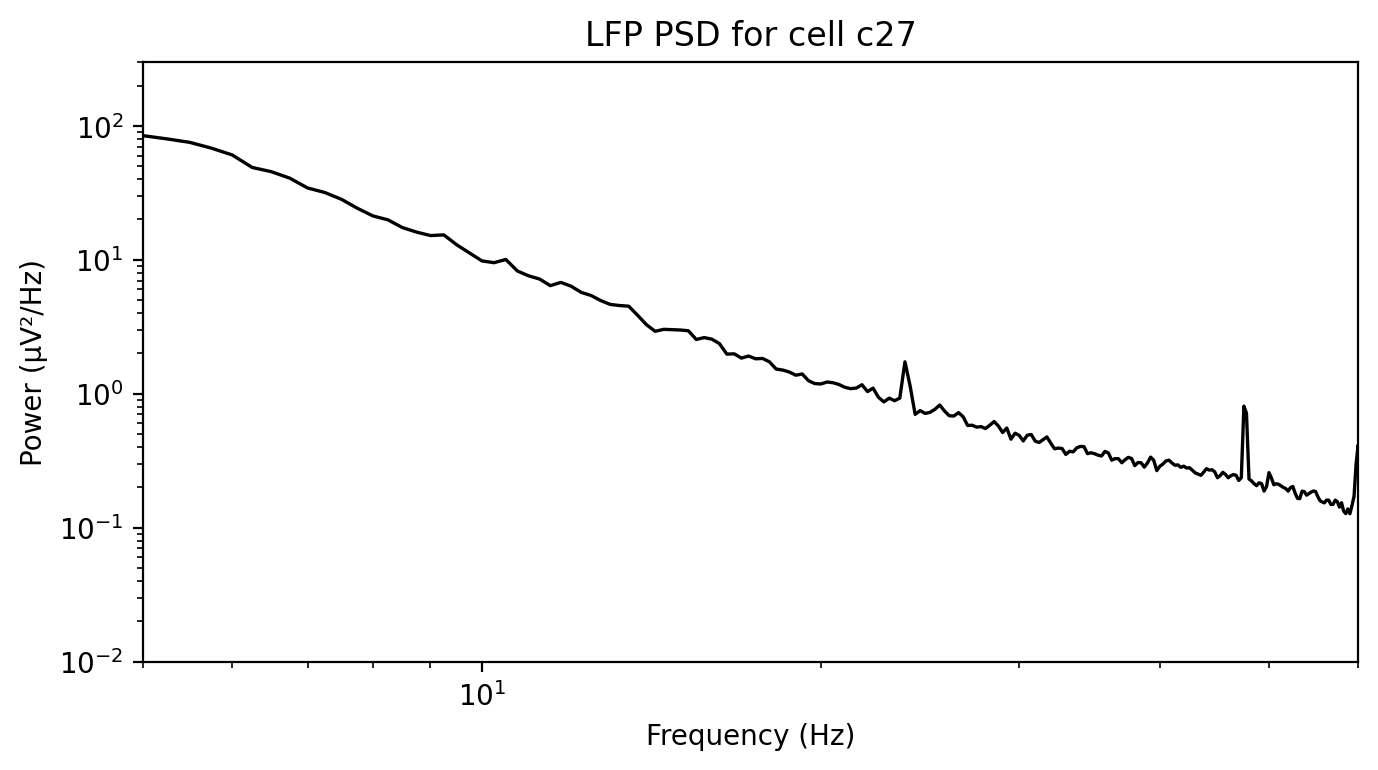

In [25]:
#Show PSD on whole recording before doing timer-resolved approach
# --- Compute PSD ---
fxx, pxx = spectral.compute_spectrum(
    lfp_filt, lfp_fs,
    method='welch',
    window='hann',
    nperseg=int(lfp_fs * 4)
)

# --- Filter for valid range ---
mask = (fxx > 0) & np.isfinite(pxx)
fxx = fxx[mask]
pxx = pxx[mask]

# --- Plot (log–log) ---
plt.figure(figsize=(7, 4))
plt.loglog(fxx, pxx, lw=1.2, color='k')

# Axis limits (normal, predictable)
plt.xlim(5, 60)             # Hz
plt.ylim(10e-3, 300)          
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (µV²/Hz)')
plt.title(f"LFP PSD for cell {cell_num}")



plt.tight_layout()
plt.show()


## Compute power spectra on windows during transition areas using multitaper, and run specparam to extract aperiodic offset, exponent + periodic params (if there) 


####  Fixed - no knee

In [46]:
# Fixed version (no knee) specparam, per transition window (no internal bars), return spectra
spec_df_fixed, spectra_fixed = run_specparam_on_transition_windows(
    windows=dyn_wins,
    times_rel=dyn_t,
    fs=lfp_fs,
    inner_window_sec=0.500,
    freq_range=(4, 100),
    n_freqs=256,
    time_bandwidth=2.0,
    decim_factor=9,
    progress=True,                   # outer loop only
    n_jobs=1,
    peak_width_limits=(4, 8),
    max_n_peaks=4,
    aperiodic_mode="fixed",
    gamma_band=(30, 60),
    gamma_space="log",
    collect_spectra=True,            # set False if you don't need the matrices
    inner_specparam_progress=False,  # hard-disable internal Specparam tqdm
)


Specparam per epoch: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [09:57<00:00,  8.79s/it]


In [48]:
# 1) Per-epoch next-spike time (relative to transition) from your dyn_df
t_next_rel_event = (dyn_df["next_time_s"] - dyn_df["onset_time_s"]).to_numpy(float)

# 2) Map each specparam epoch_id to its event index 
unique_epochs = np.array(sorted(spec_df_fixed["epoch_id"].unique()))


# Build a per-epoch vector of next-spike times aligned to spec_df_knee epoch_ids
if t_next_rel_event.size == unique_epochs.size:
    t_next_rel_epochs = t_next_rel_event.copy()
else:
    # If sizes don't match, create NaNs and fill what we can
    t_next_rel_epochs = np.full(unique_epochs.size, np.nan, float)
 
# 3) Transition is always at 0 per epoch
t0_epochs = np.zeros(unique_epochs.size, dtype=float)




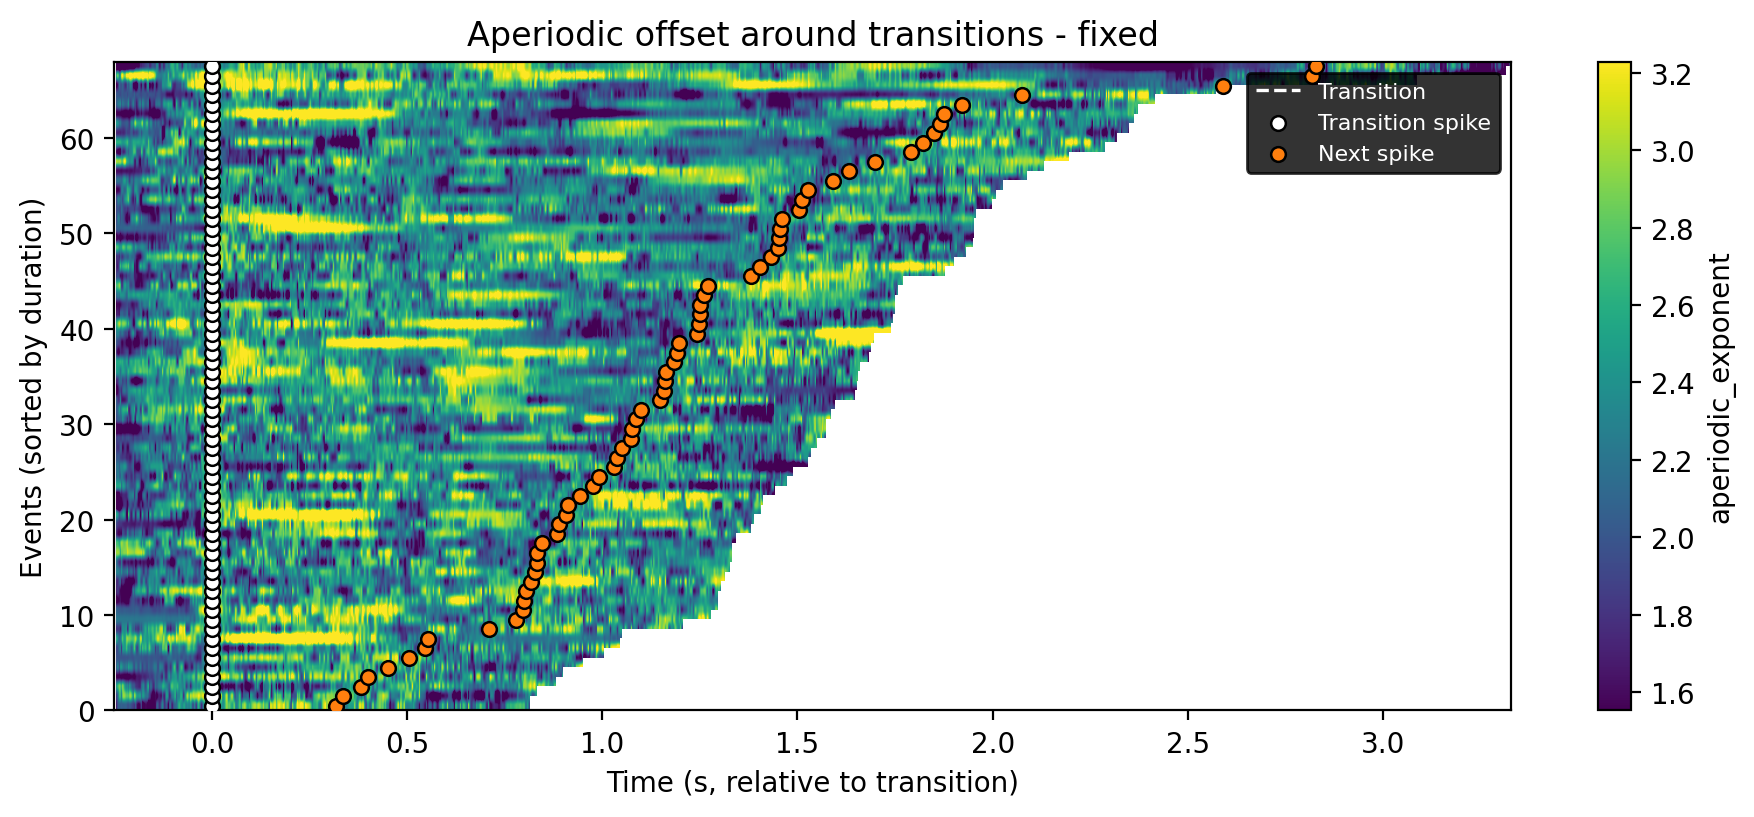

In [49]:
plot_specparam_transition_heatmap(
    spec_df_fixed,
    param="aperiodic_exponent",  # or "aperiodic_exponent", etc.
    title="Aperiodic offset around transitions - fixed",
    markers={
        "Transition spike": t0_epochs,
        
        "Next spike": t_next_rel_epochs,
    },
    # optional: tweak marker styles if you want
    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

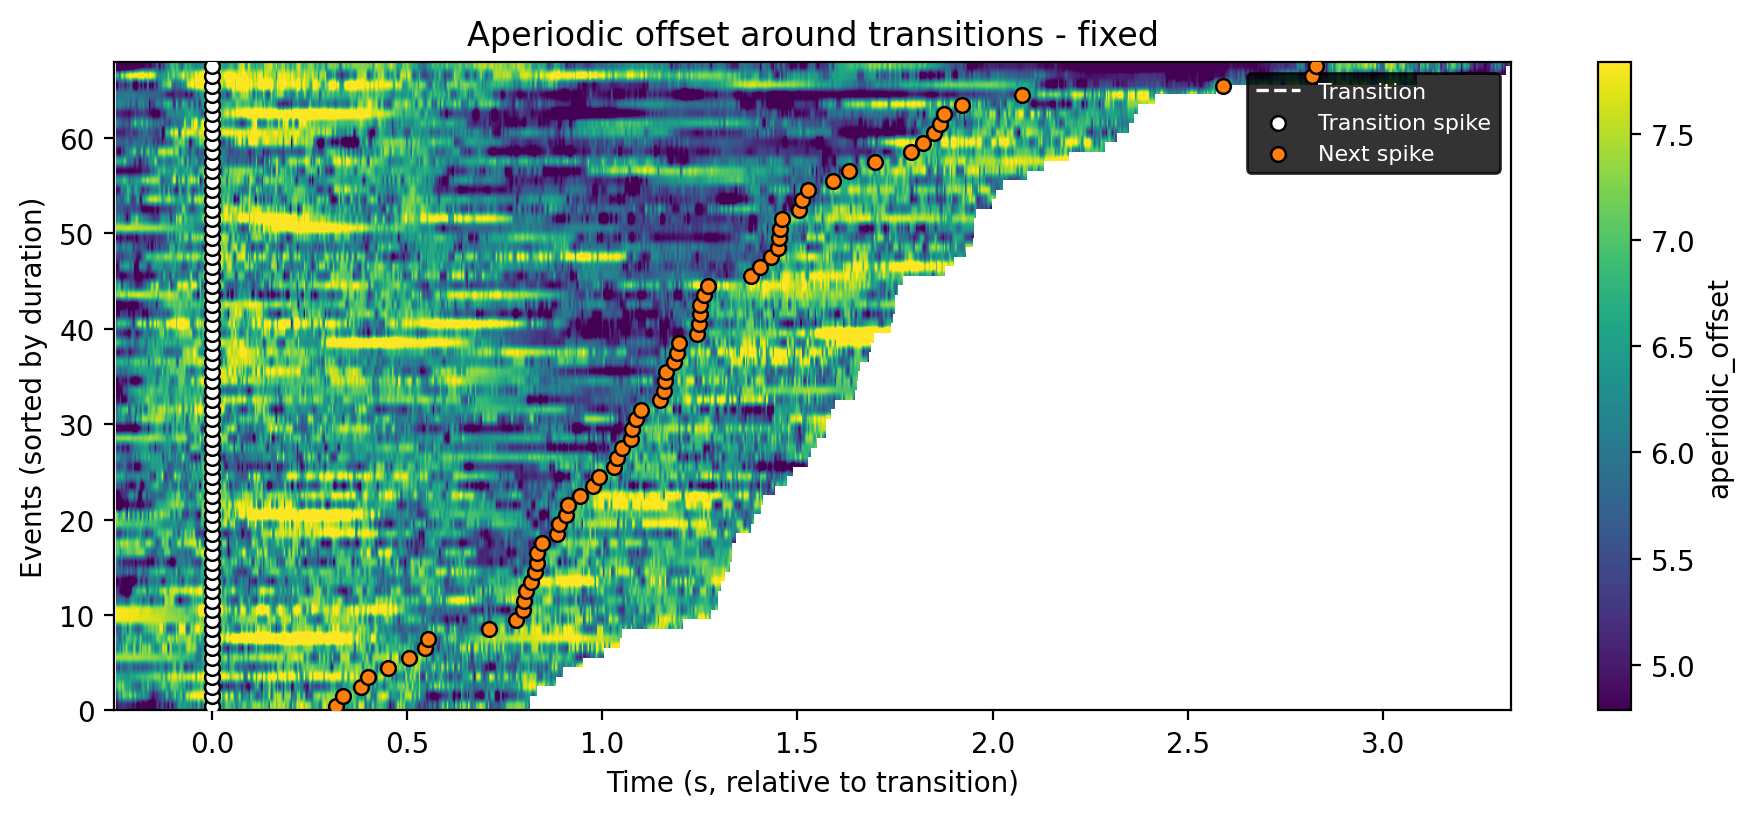

In [50]:
plot_specparam_transition_heatmap(
    spec_df_fixed,
    param="aperiodic_offset",  
    title="Aperiodic offset around transitions - fixed",
    markers={
        "Transition spike": t0_epochs,
        "Next spike": t_next_rel_epochs,
    },

    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

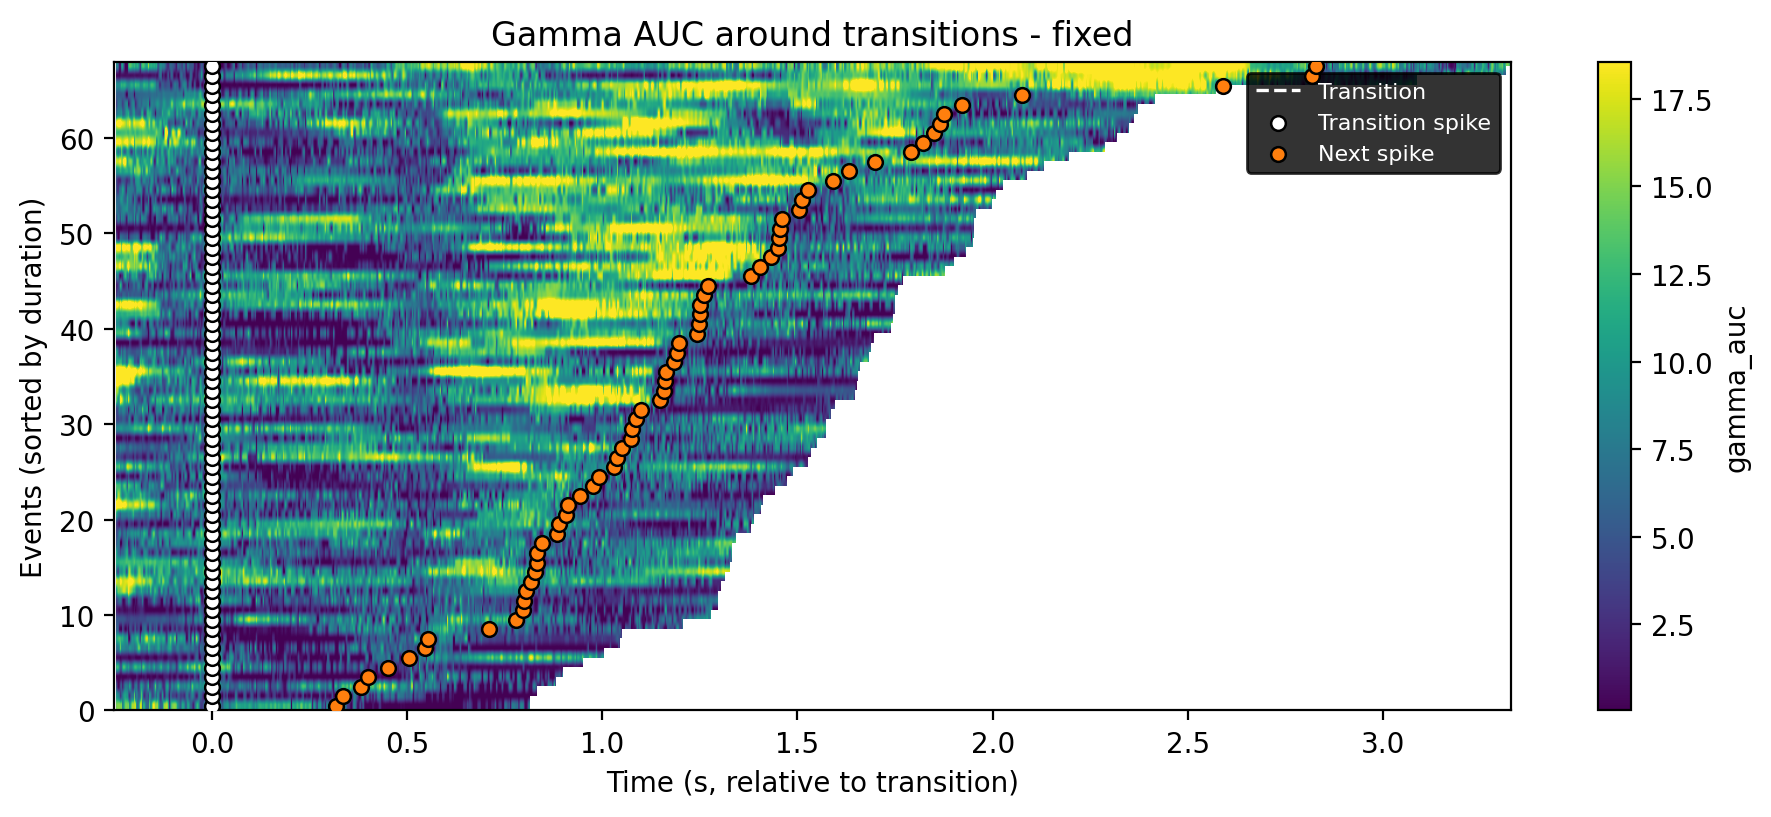

In [51]:
plot_specparam_transition_heatmap(
    spec_df_fixed,
    param="gamma_auc",  
    title="Gamma AUC around transitions - fixed",
    markers={
        "Transition spike": t0_epochs,
        "Next spike": t_next_rel_epochs,
    },

    marker_style={
        "Transition spike": dict(s=28, facecolors="white", edgecolors="black", lw=0.9, zorder=6),
        "Next spike":       dict(s=28, facecolors="#ff7f0e", edgecolors="black", lw=0.9, zorder=6),
    },
)

#### Knee version

In [ ]:
# Fixed version (no knee) specparam, per transition window (no internal bars), return spectra
spec_df_knee, spectra_knee = run_specparam_on_transition_windows(
    windows=dyn_wins,
    times_rel=dyn_t,
    fs=lfp_fs,
    inner_window_sec=0.500,
    freq_range=(4, 100),
    n_freqs=256,
    time_bandwidth=2.0,
    decim_factor=9,
    progress=True,                   # outer loop only
    n_jobs=1,
    peak_width_limits=(4, 8),
    max_n_peaks=4,
    aperiodic_mode="knee",
    gamma_band=(30, 60),
    gamma_space="log",
    collect_spectra=True,            # set False if you don't need the matrices
    inner_specparam_progress=False,  # hard-disable internal Specparam tqdm
)


Specparam per epoch:   0%|                                                                                                               | 0/68 [00:00<?, ?it/s]

In [ ]:
# 1) Per-epoch next-spike time (relative to transition) from your dyn_df
t_next_rel_event = (dyn_df["next_time_s"] - dyn_df["onset_time_s"]).to_numpy(float)

# 2) Map each specparam epoch_id to its event index 
unique_epochs = np.array(sorted(spec_df_knee["epoch_id"].unique()))


# Build a per-epoch vector of next-spike times aligned to spec_df_knee epoch_ids
if t_next_rel_event.size == unique_epochs.size:
    t_next_rel_epochs = t_next_rel_event.copy()
else:
    # If sizes don't match, create NaNs and fill what we can
    t_next_rel_epochs = np.full(unique_epochs.size, np.nan, float)
 
# 3) Transition is always at 0 per epoch
t0_epochs = np.zeros(unique_epochs.size, dtype=float)




In [ ]:
# Heatmap of aperiodic exponent across time (per-epoch rows)
plot_specparam_heatmap(
    spec_df_fixed, param="gamma_auc",
    title="Gamma AUC around transitions"
)

In [ ]:
# Heatmap of aperiodic exponent across time (per-epoch rows)
plot_specparam_heatmap(
    spec_df_fixed, param="aperiodic_exponent",
    title="Aperiodic exponent around transitions"
)

In [ ]:
import matplotlib.pyplot as plt

epoch_idx = 1  # pick any transition window
spec = spectra[epoch_idx]  # (n_bins, n_freqs)
freqs = np.linspace(1, 60, spec.shape[1])

plt.figure(figsize=(6,4))
plt.plot(freqs, spec.mean(axis=0))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²/Hz)")
plt.title(f"Mean spectrum (epoch {epoch_idx})")
plt.yscale("log")
plt.xscale("log")
plt.show()


In [ ]:
plt.figure(figsize=(8,5))
for b in range(spec.shape[0]):
    plt.plot(freqs, spec[b], alpha=0.4, lw=0.7)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²/Hz)")
plt.title(f"All bin spectra – epoch {epoch_idx}")
plt.xscale("log"); plt.yscale("log")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8,4))
plt.imshow(
    np.log10(spec + 1e-12),
    aspect='auto', origin='lower',
    extent=[freqs[0], freqs[-1], 0, spec.shape[0]],
    cmap='inferno'
)
plt.colorbar(label="log10 Power (µV²/Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Time bin (within transition)")
plt.title(f"Spectrogram – epoch {epoch_idx}")
plt.show()


In [ ]:
mean_spec = np.mean([s.mean(axis=0) for s in spectra], axis=0)

plt.figure(figsize=(6,4))
plt.plot(freqs, mean_spec, color="black")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²/Hz)")
plt.title("Average spectrum across transitions")
plt.tight_layout()
plt.show()


In [ ]:
eid = 15  # choose which epoch
spec = spectra[eid]

freqs = spec["freqs"]
full  = spec["full"]
ap    = spec["aperiodic"]
resid = spec["residual"]
times = spec["bin_times_rel"]

plt.figure(figsize=(8, 4))
for i in range(full.shape[0]):
    plt.loglog(freqs, full[i], color='gray', alpha=0.4)
plt.loglog(freqs, np.nanmean(full, axis=0), color='k', lw=2, label="Mean PSD")
plt.loglog(freqs, np.nanmean(ap, axis=0), color='r', lw=1.5, label="Mean Aperiodic")
plt.xlim(1, 90)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²/Hz)")
plt.title(f"Epoch {eid} – LFP spectra across time bins")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# 2) Or heatmap view (cleaner overview)
plt.imshow(np.log10(spec + 1e-12), aspect="auto", origin="lower",
           extent=[freqs[0], freqs[-1], 0, spec.shape[0]], cmap="inferno")
